# EDA Complementar: Data Quality, Dimensões e Temporalidade

## Objetivo deste notebook

Este notebook dá continuidade a `01_distribuicao_transacoes.ipynb`, fechando os blocos de Análise Exploratória de Dados (EDA) que ainda não haviam sido cobertos: qualidade dos dados, segmentação por dimensões operacionais, comportamento temporal e identificação de estabelecimentos fora do padrão.


In [166]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from sqlalchemy import create_engine
import os
import numpy as np
from scipy.stats import ttest_ind, levene, f_oneway,chi2_contingency,chisquare
import pingouin as pg



os.makedirs("../imagens", exist_ok=True)


In [167]:
import getpass
from sqlalchemy import URL

USUARIO = os.getenv("PGUSER", "postgres")
SENHA = os.getenv("PGPASSWORD") or getpass.getpass("Senha do PostgreSQL: ")
HOST = os.getenv("PGHOST", "localhost")
PORTA = int(os.getenv("PGPORT", "5432"))
BANCO = os.getenv("PGDATABASE", "pagamentos_analytics")

url = URL.create(
    "postgresql+psycopg2",
    username=USUARIO,
    password=SENHA,
    host=HOST,
    port=PORTA,
    database=BANCO
)

engine = create_engine(url)

print("Conectado ao banco de dados com sucesso!")


Conectado ao banco de dados com sucesso!


## 1. Data Quality

### Pergunta condutora

Os dados que já foram usados em todas as análises estatísticas de `01_distribuicao_transacoes.ipynb` têm a integridade que os resultados pressupõem?

### Por que importa

Toda a estatística feita até aqui (médias, intervalos de confiança, testes de hipótese) assume implicitamente que não há duplicidade de transação, que os tipos estão corretos e que não existem valores impossíveis. Esta seção verifica essas premissas de forma explícita, em vez de assumi-las.

As validações a seguir foram desenhadas e testadas previamente no DBeaver; aqui elas são formalizadas de forma reproduzível, no mesmo padrão SQL + `pd.read_sql` usado em `01_distribuicao_transacoes.ipynb`.


In [168]:
query_completude = """
SELECT
    COUNT(*) AS total_linhas,
    COUNT(*) FILTER (WHERE valor_bruto IS NULL) AS nulos_valor_bruto,
    COUNT(*) FILTER (WHERE quantidade_parcelas IS NULL) AS nulos_parcelas,
    COUNT(*) FILTER (WHERE data_transacao IS NULL) AS nulos_data,
    COUNT(*) FILTER (WHERE hora_transacao IS NULL) AS nulos_hora,
    COUNT(*) FILTER (WHERE estabelecimento_id IS NULL) AS nulos_estabelecimento,
    COUNT(*) FILTER (WHERE meio_pagamento_id IS NULL) AS nulos_meio_pagamento,
    COUNT(*) FILTER (WHERE valor_bruto <= 0) AS valor_impossivel,
    COUNT(*) FILTER (WHERE quantidade_parcelas <= 0) AS parcelas_impossivel
FROM transacoes;
"""

pd.read_sql(query_completude, engine)


,total_linhas,nulos_valor_bruto,nulos_parcelas,nulos_data,nulos_hora,nulos_estabelecimento,nulos_meio_pagamento,valor_impossivel,parcelas_impossivel
0,583000,0,0,0,0,0,0,0,0


### Interpretação

Nas 583.000 transações, todas as colunas centrais (`valor_bruto`, `quantidade_parcelas`, `data_transacao`, `hora_transacao`, `estabelecimento_id`, `meio_pagamento_id`) apresentaram zero nulos, e não foram encontrados valores impossíveis (`valor_bruto <= 0` ou `quantidade_parcelas <= 0`).

**Fato observado:** a base central não apresenta problemas de completude ou validade nas colunas testadas.


In [169]:
query_duplicidade = """
SELECT
    data_transacao,
    hora_transacao,
    valor_bruto,
    COALESCE(codigo_autorizacao, txid_pix) AS identificador_transacao,
    COUNT(*) AS qtd_ocorrencias
FROM transacoes
WHERE codigo_autorizacao IS NOT NULL OR txid_pix IS NOT NULL
GROUP BY data_transacao, hora_transacao, valor_bruto, COALESCE(codigo_autorizacao, txid_pix)
HAVING COUNT(*) > 1
ORDER BY qtd_ocorrencias DESC;
"""

pd.read_sql(query_duplicidade, engine)


,data_transacao,hora_transacao,valor_bruto,identificador_transacao,qtd_ocorrencias


### Interpretação

`transacao_id` é chave primária: duplicidade técnica já é impedida pela constraint do banco, então testar isso não agregaria informação nova. O que importa é duplicidade **lógica**: o mesmo evento de negócio capturado duas vezes com identificadores técnicos diferentes (por exemplo, por retry de captura na adquirente).

Como PIX preenche `txid_pix` e cartão preenche `codigo_autorizacao` (nunca os dois ao mesmo tempo), o identificador foi unificado com `COALESCE(codigo_autorizacao, txid_pix)` para cobrir os dois meios de pagamento na mesma checagem.

**Fato observado:** nenhum grupo de `(data_transacao, hora_transacao, valor_bruto, identificador)` aparece mais de uma vez.


In [170]:
query_coincidencia = """
SELECT
    data_transacao,
    hora_transacao,
    valor_bruto,
    COUNT(*) AS qtd_transacoes,
    COUNT(DISTINCT COALESCE(codigo_autorizacao, txid_pix)) AS qtd_identificadores_distintos
FROM transacoes
WHERE codigo_autorizacao IS NOT NULL OR txid_pix IS NOT NULL
GROUP BY data_transacao, hora_transacao, valor_bruto
HAVING COUNT(*) > 1
ORDER BY qtd_transacoes DESC;
"""

pd.read_sql(query_coincidencia, engine)


,data_transacao,hora_transacao,valor_bruto,qtd_transacoes,qtd_identificadores_distintos


### Interpretação

Esta segunda checagem complementa a anterior: em vez de procurar duplicidade exata, procura coincidência (mesma data, hora e valor, mas identificadores diferentes), o que distinguiria dois eventos genuinamente distintos de uma possível duplicidade disfarçada.

Como `hora_transacao` tem precisão de segundo, a chance de coincidência por acaso já é baixa.

**Fato observado:** também não há nenhuma coincidência desse tipo. Combinado com o resultado anterior, isso é evidência de que, entre as transações com `codigo_autorizacao` ou `txid_pix` preenchido, cada linha representa um evento único.

**Ressalva:** as duas queries acima filtram `WHERE codigo_autorizacao IS NOT NULL OR txid_pix IS NOT NULL`, então essa conclusão vale para o subconjunto que tem identificador, não ainda para as 583.000 linhas inteiras. A checagem seguinte mostra quantas transações ficam de fora desse filtro.

In [171]:
query_sentinela = """
SELECT *
FROM motivos_negativa
WHERE motivo_negativa_id = 0;
"""

pd.read_sql(query_sentinela, engine)


,motivo_negativa_id,motivo_negativa,categoria_motivo
0,0,Não se aplica,Não se aplica


### Interpretação

`motivo_negativa_id = 0` não é um valor nulo: é um sentinela que representa "não se aplica" (transação aprovada, sem motivo de negativa). A constraint de chave estrangeira em `transacoes` exige que esse valor exista na tabela `motivos_negativa`.

**Fato observado:** o valor 0 está documentado na tabela de lookup como `motivo_negativa = "Não se aplica"`, `categoria_motivo = "Não se aplica"`, confirmando que o sentinela é uma convenção de modelagem válida, não uma inconsistência.

Isso já vai direto para o dicionário de dados: `motivo_negativa_id` não deve ser tratado como "motivo de negativa" sem excluir ou isolar o valor 0 primeiro.


In [172]:
query_consistencia_meio = """
SELECT
    meio_pagamento_id,
    COUNT(*) AS total,
    COUNT(*) FILTER (WHERE codigo_autorizacao IS NOT NULL AND txid_pix IS NOT NULL) AS preencheu_os_dois,
    COUNT(*) FILTER (WHERE codigo_autorizacao IS NULL AND txid_pix IS NULL) AS nao_preencheu_nenhum
FROM transacoes
GROUP BY meio_pagamento_id
ORDER BY meio_pagamento_id;
"""

pd.read_sql(query_consistencia_meio, engine)


,meio_pagamento_id,total,preencheu_os_dois,nao_preencheu_nenhum
0,1,222331,0,0
1,2,98780,0,4644
2,3,261889,0,18505


### Interpretação

**Fato observado:** 23.149 transações (4.644 do `meio_pagamento_id=2` e 18.505 do `meio_pagamento_id=3`) não têm `codigo_autorizacao` nem `txid_pix` preenchidos, cerca de 4% da base. Nenhuma linha preenche os dois campos ao mesmo tempo, confirmando sem exceção a regra de exclusividade (cartão preenche um, PIX preenche o outro).

**Inferência:** essas 23.149 linhas ficaram fora das duas checagens de duplicidade anteriores, porque ambas dependiam de `COALESCE(codigo_autorizacao, txid_pix)`. Antes desta revisão, a conclusão dizia que "as 583.000 linhas são 583.000 eventos únicos", generalizando para uma população que não tinha sido testada, essa checagem expõe exatamente onde estava a lacuna.

**Validação (fechamento):** as duas checagens propostas acima foram rodadas. A primeira, quebra por `status_id`, confirma a hipótese: as 23.149 linhas sem identificador são 100% `status_id=2` (Negada), 4.644 do `meio_pagamento_id=2` e 18.505 do `meio_pagamento_id=3`. Faz sentido, uma transação negada nunca chega a ser autorizada pela adquirente ou pelo Banco Central, então não existe `codigo_autorizacao`/`txid_pix` pra gerar.

A segunda, duplicidade dentro desse subconjunto usando a chave `estabelecimento_id + adquirente_id + data_transacao + hora_transacao + valor_bruto` (que não depende de `codigo_autorizacao`/`txid_pix`), não retornou nenhuma linha, nenhum grupo duplicado encontrado.

Com isso, a lacuna identificada acima fica fechada: não foram encontradas evidências de duplicidade lógica nas 583.000 transações, agora cobrindo tanto o subconjunto com identificador quanto o subconjunto sem.


## 2. Segmentação por Dimensão: Taxa de Aprovação

Pergunta condutora: a taxa de aprovação varia de forma relevante entre meio de pagamento, bandeira, adquirente, canal de captura e horário, ou é praticamente homogênea?

Régua de comparação: a taxa geral da base (calculada a seguir) serve de baseline. Cada dimensão é comparada contra ela, e cada diferença encontrada é testada formalmente com qui-quadrado de independência antes de ser tratada como "real".


### Nota metodológica: correção da definição de taxa de aprovação

Durante a Seção 3, cruzamos os números desta seção com um dashboard de Power BI já existente. A contagem de aprovadas, o TPV e o ticket médio bateram exatamente, mas a taxa de aprovação não. A causa: as queries abaixo calculavam `taxa_aprovacao_pct = aprovadas / total_transacoes`, incluindo Cancelada (`status_id = 3`) e Estornada (`status_id = 4`) no denominador. Essas duas situações só acontecem **depois** de uma aprovação, não são resultado de uma tentativa de autorização, então não deveriam contar como "tentativa" na taxa de aprovação.

**Definição corrigida, usada a partir daqui:** `taxa_aprovacao_pct = aprovadas / (aprovadas + negadas)`, excluindo Cancelada e Estornada da base de cálculo (`WHERE status_id IN (1, 2)`). O efeito medido em fevereiro/março foi de ~1,2 a 1,3 pontos percentuais: pequeno, mas real. Todas as queries e os testes qui-quadrado desta seção foram atualizados; os números e interpretações abaixo já foram reexecutados e revisados com os resultados novos.

In [173]:
query_taxa_geral = """
SELECT
    COUNT(*) AS total_transacoes,
    COUNT(*) FILTER (WHERE status_id = 1) AS total_aprovadas,
    ROUND(
        COUNT(*) FILTER (WHERE status_id = 1) * 100.0 / COUNT(*),
        2
    ) AS taxa_aprovacao_pct
FROM transacoes
WHERE status_id IN (1, 2);  -- exclui Cancelada/Estornada: evento pós-aprovação, não é tentativa
"""

pd.read_sql(query_taxa_geral, engine)

,total_transacoes,total_aprovadas,taxa_aprovacao_pct
0,575271,548006,95.26


### Interpretação

**Fato observado:** taxa de aprovação geral de 95,26% (548.006 aprovadas de 575.271 tentativas, já excluindo Cancelada/Estornada, ver nota metodológica acima). Essa é a régua de comparação para todas as dimensões a seguir: segmentos bem abaixo disso são candidatos a investigação; próximos indicam homogeneidade.

In [174]:
query_taxa_bandeira = """
SELECT
    COALESCE(b.bandeira, 'Sem bandeira (provável PIX)') AS bandeira,
    COUNT(*) AS total_transacoes,
    COUNT(*) FILTER (WHERE t.status_id = 1) AS total_aprovadas,
    ROUND(
        COUNT(*) FILTER (WHERE t.status_id = 1) * 100.0 / COUNT(*),
        2
    ) AS taxa_aprovacao_pct
FROM transacoes t
LEFT JOIN bandeiras b
    ON t.bandeira_id = b.bandeira_id
WHERE t.status_id IN (1, 2)  -- exclui Cancelada/Estornada
GROUP BY COALESCE(b.bandeira, 'Sem bandeira (provável PIX)')
ORDER BY taxa_aprovacao_pct DESC;
"""

pd.read_sql(query_taxa_bandeira, engine)

,bandeira,total_transacoes,total_aprovadas,taxa_aprovacao_pct
0,Não se aplica,220356,216240,98.13
1,Hipercard,15534,14602,94.00
2,Visa,142994,133752,93.54
3,Mastercard,149743,139920,93.44
4,Elo,34606,32301,93.34
5,American Express,12038,11191,92.96


### Interpretação

**Fato observado:** o grupo sem bandeira (`bandeira_id = 0`, sentinela de PIX) tem 220.356 transações e 98,13% de aprovação, bem acima da régua. As cinco bandeiras de cartão ficam entre 92,96% (American Express) e 94,00% (Hipercard), um intervalo de só 1,04 ponto entre elas: homogêneas entre si, mas todas abaixo da régua geral.

`bandeira_id = 0` não é nulo: existe como linha real na tabela `bandeiras` ("Não se aplica"), o mesmo padrão de sentinela documentado usado em `motivo_negativa_id`.

In [175]:
df_bandeira = pd.read_sql(query_taxa_bandeira, engine)

pix = df_bandeira[df_bandeira["bandeira"] == "Não se aplica"]
cartao = df_bandeira[df_bandeira["bandeira"] != "Não se aplica"]

aprovadas_pix = pix["total_aprovadas"].sum()
total_pix = pix["total_transacoes"].sum()
aprovadas_cartao = cartao["total_aprovadas"].sum()
total_cartao = cartao["total_transacoes"].sum()

tabela = np.array([
    [aprovadas_pix, total_pix - aprovadas_pix],           # PIX: aprovadas, não aprovadas
    [aprovadas_cartao, total_cartao - aprovadas_cartao],   # Cartão: aprovadas, não aprovadas
])

chi2, p, dof, esperado = chi2_contingency(tabela)

n = tabela.sum()
cramer_v = np.sqrt(chi2 / (n * (min(tabela.shape) - 1)))

print(f"Qui-quadrado: {chi2:.2f}")
print(f"p-valor: {p:.2e}")
print(f"Graus de liberdade: {dof}")
print(f"Cramér's V (tamanho do efeito): {cramer_v:.4f}")

Qui-quadrado: 6522.47
p-valor: 0.00e+00
Graus de liberdade: 1
Cramér's V (tamanho do efeito): 0.1065


### Interpretação

**Inferência estatística:** qui-quadrado = 6.522,47, p ≈ 0: rejeitamos H0, há associação real entre PIX/Cartão e aprovação.

**Tamanho do efeito:** Cramér's V = 0,1065: classificado como **pequeno** (limiar de Cohen para tabela 2×2: ~0,10 pequeno, ~0,30 moderado, ~0,50 grande), passando levemente o limiar. Diferente do caso Hotelaria × Eletrônicos do notebook 01 (significativo, porém desprezível), aqui o efeito é significativo **e** mensurável, ainda que modesto. PIX aprova 98,13% contra 93,48% do Cartão (blend de todas as bandeiras), gap bruto de 4,65 pontos.

**Negócio:** PIX aprova mais que cartão de forma consistente: coerente com não passar pelas mesmas barreiras de risco de crédito e limite que um cartão passa.

In [176]:
query_taxa_adquirente = """
SELECT
    a.nome_resumido AS adquirente,
    COUNT(*) AS total_transacoes,
    COUNT(*) FILTER (WHERE t.status_id = 1) AS total_aprovadas,
    ROUND(
        COUNT(*) FILTER (WHERE t.status_id = 1) * 100.0 / COUNT(*),
        2
    ) AS taxa_aprovacao_pct
FROM transacoes t
LEFT JOIN adquirentes a
    ON t.adquirente_id = a.adquirente_id
WHERE t.status_id IN (1, 2)  -- exclui Cancelada/Estornada
GROUP BY a.nome_resumido
ORDER BY taxa_aprovacao_pct DESC;
"""

pd.read_sql(query_taxa_adquirente, engine)

,adquirente,total_transacoes,total_aprovadas,taxa_aprovacao_pct
0,Áurea,177676,169989,95.67
1,Nexo,201978,192739,95.43
2,Prisma,125105,118788,94.95
3,Vértice,70512,66490,94.30


### Interpretação

**Fato observado:** Áurea 95,67%, Nexo 95,43%, Prisma 94,95%, Vértice 94,30%: intervalo de 1,37 ponto entre a maior e a menor. As quatro adquirentes somam exatamente 575.271 transações, confirmando completude de `adquirente_id` na nova base (aprovada + negada).

In [177]:
df_adquirente = pd.read_sql(query_taxa_adquirente, engine)

tabela_adquirente = np.column_stack([
    df_adquirente["total_aprovadas"],
    df_adquirente["total_transacoes"] - df_adquirente["total_aprovadas"]
])

chi2_adq, p_adq, dof_adq, esperado_adq = chi2_contingency(tabela_adquirente)

n_adq = tabela_adquirente.sum()
cramer_v_adq = np.sqrt(chi2_adq / (n_adq * (min(tabela_adquirente.shape) - 1)))

print(f"Qui-quadrado: {chi2_adq:.2f}")
print(f"p-valor: {p_adq:.2e}")
print(f"Graus de liberdade: {dof_adq}")
print(f"Cramér's V (tamanho do efeito): {cramer_v_adq:.4f}")

Qui-quadrado: 251.26
p-valor: 3.50e-54
Graus de liberdade: 3
Cramér's V (tamanho do efeito): 0.0209


### Interpretação

**Inferência estatística:** qui-quadrado = 251,26, p = 3,50e-54: estatisticamente significativo.

**Tamanho do efeito:** Cramér's V = 0,0209: **desprezível**, bem abaixo do limiar de 0,10. Mesmo padrão do teste Hotelaria × Eletrônicos no notebook 01: significativo por causa do volume grande da amostra, mas sem relevância prática.

**Negócio:** isoladamente, a adquirente não é um fator relevante de aprovação nesta base, apesar da significância estatística. (As adquirentes têm, sim, volumes de transação bem diferentes entre si: Nexo concentra 201.978, Vértice só 70.512; mas isso é uma questão de distribuição de carteira, não de performance de aprovação.)

In [178]:
query_taxa_canal = """
SELECT
    c.canal_captura,
    COUNT(*) AS total_transacoes,
    COUNT(*) FILTER (WHERE t.status_id = 1) AS total_aprovadas,
    ROUND(
        COUNT(*) FILTER (WHERE t.status_id = 1) * 100.0 / COUNT(*),
        2
    ) AS taxa_aprovacao_pct
FROM transacoes t
LEFT JOIN canais_captura c
    ON t.canal_captura_id = c.canal_captura_id
WHERE t.status_id IN (1, 2)  -- exclui Cancelada/Estornada
GROUP BY c.canal_captura
ORDER BY taxa_aprovacao_pct DESC;
"""

pd.read_sql(query_taxa_canal, engine)

,canal_captura,total_transacoes,total_aprovadas,taxa_aprovacao_pct
0,POS,527849,505014,95.67
1,Link de Pagamento,47422,42992,90.66


### Interpretação

**Fato observado:** POS 95,67% (527.849 transações), Link de Pagamento 90,66% (47.422 transações): diferença de 5,01 pontos, ainda a maior amplitude bruta encontrada até aqui.

In [179]:
df_canal = pd.read_sql(query_taxa_canal, engine)

tabela_canal = np.column_stack([
    df_canal["total_aprovadas"],
    df_canal["total_transacoes"] - df_canal["total_aprovadas"]
])

chi2_canal, p_canal, dof_canal, esperado_canal = chi2_contingency(tabela_canal)

n_canal = tabela_canal.sum()
cramer_v_canal = np.sqrt(chi2_canal / (n_canal * (min(tabela_canal.shape) - 1)))

print(f"Qui-quadrado: {chi2_canal:.2f}")
print(f"p-valor: {p_canal:.2e}")
print(f"Graus de liberdade: {dof_canal}")
print(f"Cramér's V (tamanho do efeito): {cramer_v_canal:.4f}")

Qui-quadrado: 2423.37
p-valor: 0.00e+00
Graus de liberdade: 1
Cramér's V (tamanho do efeito): 0.0649


### Interpretação

**Inferência estatística:** qui-quadrado = 2.423,37, p ≈ 0: estatisticamente significativo.

**Tamanho do efeito:** Cramér's V = 0,0649: abaixo do limiar de "pequeno" (0,10), mas bem acima de adquirente (0,0209). Vale notar: apesar do gap bruto (5,01 pontos) ser maior que o de PIX × Cartão (4,65 pontos), o V de canal ficou menor; o desbalanceamento de tamanho entre os grupos (527 mil POS contra 47 mil Link) também molda o tamanho do efeito padronizado, não só a diferença percentual.

**Negócio:** Link de Pagamento aprovar menos é esperado: é usado em poucos cenários e tende a ser uma transação *card-not-present*, historicamente mais sujeita a recusa. O desbalanceamento de volume entre os dois canais (~11 para 1) é, em si, um ponto de atenção para uma futura etapa de Machine Learning (desbalanceamento de representação entre categorias do canal, a distinguir do desbalanceamento de classes do alvo Aprovada/Negada), não um problema de qualidade agora.

In [180]:
query_taxa_hora = """
SELECT
    EXTRACT(HOUR FROM hora_transacao) AS hora_do_dia,
    COUNT(*) AS total_transacoes,
    COUNT(*) FILTER (WHERE status_id = 1) AS total_aprovadas,
    ROUND(
        COUNT(*) FILTER (WHERE status_id = 1) * 100.0 / COUNT(*),
        2
    ) AS taxa_aprovacao_pct
FROM transacoes
WHERE status_id IN (1, 2)  -- exclui Cancelada/Estornada
GROUP BY EXTRACT(HOUR FROM hora_transacao)
ORDER BY hora_do_dia;
"""

pd.read_sql(query_taxa_hora, engine)

,hora_do_dia,total_transacoes,total_aprovadas,taxa_aprovacao_pct
0,0.0,1641,1562,95.19
1,1.0,1688,1612,95.50
2,2.0,1692,1616,95.51
3,3.0,1668,1572,94.24
4,4.0,1682,1580,93.94
5,5.0,3485,3362,96.47
6,6.0,7095,6802,95.87
7,7.0,19492,18523,95.03
8,8.0,26180,24989,95.45
9,9.0,33245,31598,95.05


### Interpretação

**Fato observado:** taxa varia de 93,94% (4h) a 96,47% (5h): amplitude de 2,53 pontos. O volume por hora continua muito desigual: madrugada (0h-6h) tem entre 1.641 e 7.095 transações; horário comercial tem ~20 mil a 47 mil. As estimativas da madrugada são baseadas em bem menos dados, portanto mais instáveis.

In [181]:
df_hora = pd.read_sql(query_taxa_hora, engine)

tabela_hora = np.column_stack([
    df_hora["total_aprovadas"],
    df_hora["total_transacoes"] - df_hora["total_aprovadas"]
])

chi2_hora, p_hora, dof_hora, esperado_hora = chi2_contingency(tabela_hora)

n_hora = tabela_hora.sum()
cramer_v_hora = np.sqrt(chi2_hora / (n_hora * (min(tabela_hora.shape) - 1)))

print(f"Qui-quadrado: {chi2_hora:.2f}")
print(f"p-valor: {p_hora:.2e}")
print(f"Graus de liberdade: {dof_hora}")
print(f"Cramér's V (tamanho do efeito): {cramer_v_hora:.4f}")

Qui-quadrado: 55.91
p-valor: 1.46e-04
Graus de liberdade: 23
Cramér's V (tamanho do efeito): 0.0099


### Interpretação

**Inferência estatística:** qui-quadrado = 55,91, p = 1,46e-04: estatisticamente significativo.

**Tamanho do efeito:** Cramér's V = 0,0099: o menor entre todas as dimensões testadas, **desprezível**.

**Negócio:** horário do dia não é um fator relevante para explicar variação de aprovação: a operação é estável ao longo do dia. A significância residual é compatível com o menor volume (logo, maior ruído) das horas de madrugada, não com um efeito operacional real.

In [182]:
df_bandeira = pd.read_sql(query_taxa_bandeira, engine).rename(columns={"bandeira": "categoria"})
df_bandeira["dimensao"] = "Bandeira"
df_bandeira["categoria"] = df_bandeira["categoria"].replace("Não se aplica", "PIX")

df_adquirente = pd.read_sql(query_taxa_adquirente, engine).rename(columns={"adquirente": "categoria"})
df_adquirente["dimensao"] = "Adquirente"

df_canal = pd.read_sql(query_taxa_canal, engine).rename(columns={"canal_captura": "categoria"})
df_canal["dimensao"] = "Canal de captura"

df_hora_plot = df_hora.copy()
df_hora_plot["categoria"] = df_hora_plot["hora_do_dia"].astype(int).astype(str) + "h"
df_hora_plot["dimensao"] = "Horário"

query_taxa_meio_pagamento = """
SELECT
    m.meio_pagamento AS categoria,
    COUNT(*) AS total_transacoes,
    COUNT(*) FILTER (WHERE t.status_id = 1) AS total_aprovadas,
    ROUND(
        COUNT(*) FILTER (WHERE t.status_id = 1) * 100.0 / COUNT(*),
        2
    ) AS taxa_aprovacao_pct
FROM transacoes t
JOIN meios_pagamento m
    ON t.meio_pagamento_id = m.meio_pagamento_id
WHERE t.status_id IN (1, 2)  -- exclui Cancelada/Estornada
GROUP BY m.meio_pagamento
ORDER BY taxa_aprovacao_pct DESC;
"""

df_meio_pagamento = pd.read_sql(query_taxa_meio_pagamento, engine)
df_meio_pagamento["dimensao"] = "Meio de pagamento"

colunas = ["categoria", "dimensao", "total_transacoes", "taxa_aprovacao_pct"]
volumetria = pd.concat([
    df_bandeira[colunas],
    df_adquirente[colunas],
    df_canal[colunas],
    df_hora_plot[colunas],
    df_meio_pagamento[colunas],
], ignore_index=True)

volumetria

,categoria,dimensao,total_transacoes,taxa_aprovacao_pct
0,PIX,Bandeira,220356,98.13
1,Hipercard,Bandeira,15534,94.00
2,Visa,Bandeira,142994,93.54
3,Mastercard,Bandeira,149743,93.44
4,Elo,Bandeira,34606,93.34
5,American Express,Bandeira,12038,92.96
6,Áurea,Adquirente,177676,95.67
7,Nexo,Adquirente,201978,95.43
8,Prisma,Adquirente,125105,94.95
9,Vértice,Adquirente,70512,94.30


### Nota metodológica

Para esta tabela consolidada, o rótulo "Não se aplica" (sentinela de bandeira para PIX) foi renomeado para "PIX", só para leitura, o dado na tabela `bandeiras` continua com o sentinela original, nada foi alterado no banco.

PIX aparece duas vezes na tabela (uma como categoria de `Bandeira`, outra como categoria de `Meio de pagamento`) com os mesmos números (220.356 / 98,13%): é a mesma fatia de dado vista por dois agrupamentos diferentes, não duplicidade.

Novidade: separar Débito (95,24%) de Crédito (92,81%) (antes agregados em "Cartão" no teste PIX × Cartão) revela 2,43 pontos de diferença entre os dois, algo que a segmentação por bandeira não capturava.

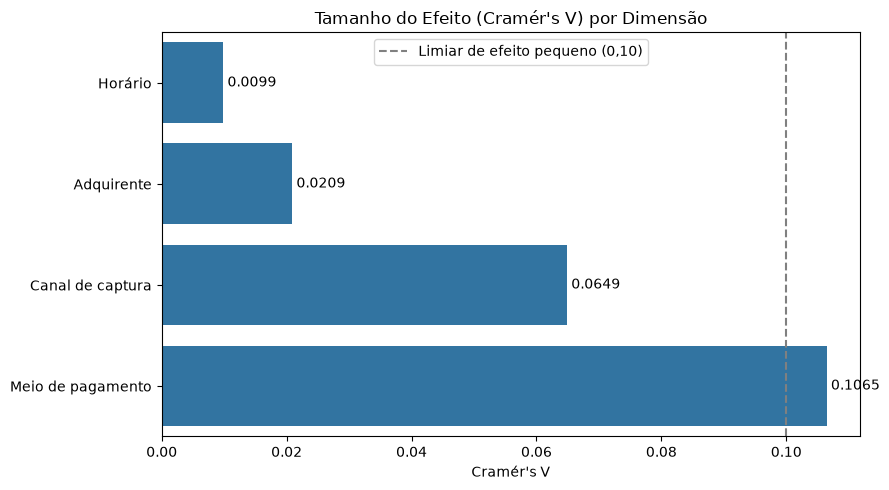

In [183]:
resumo_dimensoes = pd.DataFrame({
    "dimensao": ["Meio de pagamento", "Canal de captura", "Adquirente", "Horário"],
    "cramer_v": [cramer_v, cramer_v_canal, cramer_v_adq, cramer_v_hora]
}).sort_values("cramer_v", ascending=True)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=resumo_dimensoes,
    y="dimensao",
    x="cramer_v"
)

plt.axvline(0.10, linestyle="--", linewidth=1.5, color="gray", label="Limiar de efeito pequeno (0,10)")

plt.title("Tamanho do Efeito (Cramér's V) por Dimensão")
plt.xlabel("Cramér's V")
plt.ylabel("")
plt.legend()

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.tight_layout()

plt.savefig(
    "../imagens/cramers_v_dimensoes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretação

Ranking final de tamanho de efeito:

| Dimensão | Cramér's V | Classificação |
|---|---:|---|
| Meio de pagamento (PIX × Cartão) | 0,1065 | pequeno |
| Canal de captura | 0,0649 | abaixo de pequeno |
| Adquirente | 0,0209 | desprezível |
| Horário | 0,0099 | desprezível |

Meio de pagamento é a dimensão mais relevante entre as testadas com qui-quadrado, mesmo assim, um efeito pequeno. A ordem de relevância entre as quatro dimensões não mudou com a correção da taxa de aprovação (só os valores absolutos).

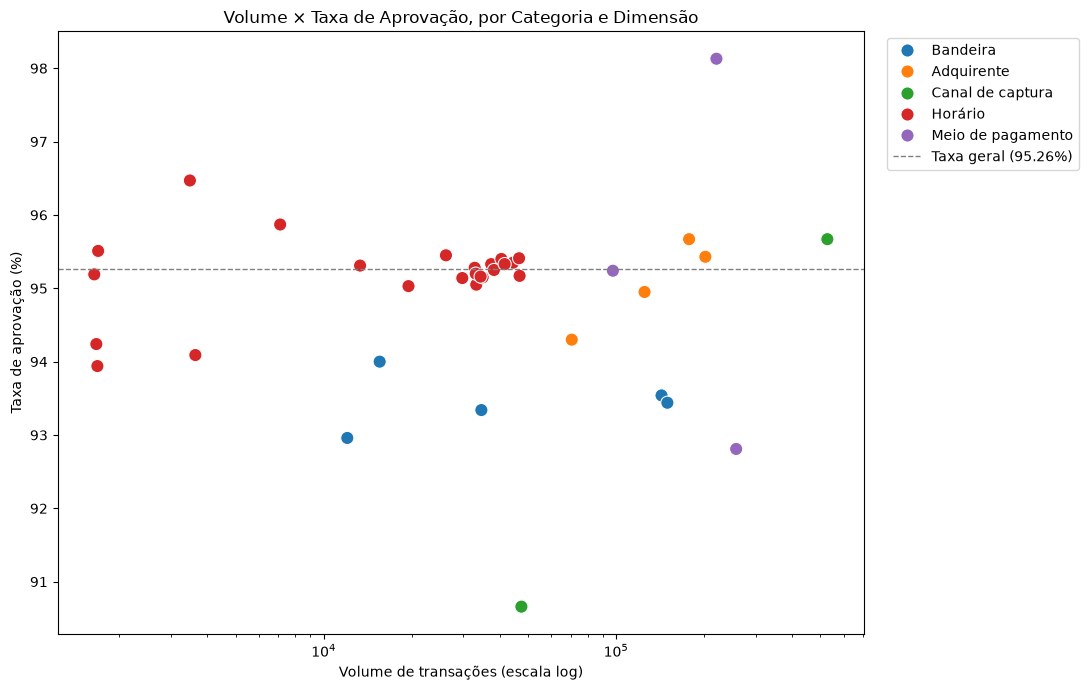

In [184]:
taxa_geral_pct = pd.read_sql(query_taxa_geral, engine)["taxa_aprovacao_pct"].iloc[0]

plt.figure(figsize=(11, 7))

ax = sns.scatterplot(
    data=volumetria,
    x="total_transacoes",
    y="taxa_aprovacao_pct",
    hue="dimensao",
    s=90
)

ax.set_xscale("log")

plt.axhline(taxa_geral_pct, linestyle="--", linewidth=1, color="gray", label=f"Taxa geral ({taxa_geral_pct:.2f}%)")

plt.title("Volume × Taxa de Aprovação, por Categoria e Dimensão")
plt.xlabel("Volume de transações (escala log)")
plt.ylabel("Taxa de aprovação (%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig(
    "../imagens/volume_x_aprovacao.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretação

**Fato observado:** os pontos de horário com baixo volume (madrugada, 0h-6h, 1.641-7.095 transações) se espalham entre 93,94% e 96,47%: 2,53 pontos de amplitude. Os de alto volume (horário comercial, 8h-21h, 26.180-46.758 transações) ficam entre 95,05% e 95,45%: só 0,40 ponto. Já Link de Pagamento (canal, ~47 mil transações, 90,66%) e Crédito (meio de pagamento, ~257 mil transações, 92,81%) ficam bem abaixo da régua geral (95,26%) mesmo com volume alto o suficiente para uma estimativa estável.

**Inferência estatística:** o padrão "funil" se confirma para horário: a dispersão na madrugada é majoritariamente ruído amostral (erro padrão maior com menos observações), mesma lógica já estudada no notebook 01. Esse padrão **não** explica Link de Pagamento nem Crédito: ambos têm volume suficiente para estimativa estável e mesmo assim ficam consistentemente abaixo da régua: evidência de diferença estrutural, não estatística.

**Negócio:** não existe, na prática, um "horário de risco" que justifique ação: a variação por hora é majoritariamente ruído. Link de Pagamento e Crédito são, sim, pontos reais de atenção, compatíveis com maior exposição a recusa (transação *card-not-present* e análise de crédito mais rigorosa, respectivamente).

### Síntese da Seção 2

- Das dimensões com teste formal (meio de pagamento, canal, adquirente, horário), todas mostraram associação estatisticamente significativa com a aprovação (esperado, dado o volume da base); bandeira foi explorada de forma descritiva, sem teste formal próprio, e o meio de pagamento de três categorias (Crédito/Débito/PIX) também não recebeu um teste formal dedicado, só o binário PIX×Cartão.
- Em tamanho de efeito, só meio de pagamento (0,1065) e, em menor grau, canal de captura (0,0649) têm relevância prática. Adquirente e horário são, na prática, homogêneos.
- O gráfico de volume × taxa mostrou que boa parte da dispersão de horário é ruído amostral, enquanto Link de Pagamento e Crédito são diferenças reais, não explicadas por tamanho de amostra.
- Duas notas para etapas futuras: (1) desbalanceamento de volume entre POS e Link de Pagamento (~11 para 1) é relevante para a etapa de avaliação de modelos (desbalanceamento de representação entre categorias do canal, a distinguir do desbalanceamento de classes do alvo); (2) distribuição desigual de volume entre adquirentes é uma questão de carteira/mercado, não de performance.

**Resposta à pergunta condutora:** a taxa de aprovação varia estatisticamente em todas as dimensões testadas, mas na prática a única diferença que merece atenção de negócio é estrutural (meio de pagamento e canal de captura), não operacional. Adquirente e horário não indicam problema.

## 3. Análise Temporal

Pergunta condutora: o volume de transações se comporta de forma estável ao longo do tempo, ou há tendência/sazonalidade visível? Começamos pela granularidade mais simples (dia da semana) antes de avançar para a série temporal completa.

### 3.1 Volume e Taxa de Aprovação por Dia da Semana

In [185]:
query_taxa_dia_semana = """
SELECT
    EXTRACT(DOW FROM data_transacao) AS dia_semana_num,
    CASE EXTRACT(DOW FROM data_transacao)
        WHEN 0 THEN 'Domingo'
        WHEN 1 THEN 'Segunda'
        WHEN 2 THEN 'Terça'
        WHEN 3 THEN 'Quarta'
        WHEN 4 THEN 'Quinta'
        WHEN 5 THEN 'Sexta'
        WHEN 6 THEN 'Sábado'
    END AS dia_semana,
    COUNT(*) AS total_transacoes,
    COUNT(*) FILTER (WHERE status_id IN (1, 2)) AS total_tentativas,
    COUNT(*) FILTER (WHERE status_id = 1) AS total_aprovadas,
    ROUND(
        COUNT(*) FILTER (WHERE status_id = 1) * 100.0 /
            NULLIF(COUNT(*) FILTER (WHERE status_id IN (1, 2)), 0),
        2
    ) AS taxa_aprovacao_pct
FROM transacoes
GROUP BY EXTRACT(DOW FROM data_transacao)
ORDER BY dia_semana_num;
"""

pd.read_sql(query_taxa_dia_semana, engine)

,dia_semana_num,dia_semana,total_transacoes,total_tentativas,total_aprovadas,taxa_aprovacao_pct
0,0.0,Domingo,76023,75051,71552,95.34
1,1.0,Segunda,86929,85803,81662,95.17
2,2.0,Terça,82717,81591,77656,95.18
3,3.0,Quarta,81877,80832,77017,95.28
4,4.0,Quinta,84620,83517,79620,95.33
5,5.0,Sexta,90583,89359,85159,95.30
6,6.0,Sábado,80251,79118,75340,95.22


### Interpretação

**Fato observado:** o volume varia por dia da semana, de 76.023 transações (domingo, o menor) a 90.583 (sexta, o maior). Com a definição corrigida (aprovadas/tentativas, `status_id IN (1, 2)`), a taxa de aprovação vai de 95,17% (segunda) a 95,34% (domingo), amplitude de apenas 0,17 ponto percentual, e fica bem próxima da régua geral de 95,26% em todos os dias.

**Negócio:** volume tem leitura mista frente à expectativa inicial de mercado (sexta e sábado como picos, domingo em queda): sexta se confirma como o maior volume e domingo como o menor, mas sábado (80.251) fica entre os volumes mais baixos, não acompanha o padrão típico de varejo físico de fim de semana. A taxa de aprovação, como esperado, não varia de forma relevante por dia da semana, coerente com a Seção 2, onde aprovação se mostrou ligada a meio de pagamento e canal, não a variáveis temporais.

**Próximo passo:** para não decidir "existe padrão" só visualmente, vamos formalizar o padrão de volume com um teste de aderência (*goodness-of-fit*), comparando a distribuição observada contra o esperado proporcional à quantidade de ocorrências de cada dia da semana no período (não mais uma divisão uniforme por 7).

In [186]:
query_ocorrencias_dia_semana = """
SELECT
    EXTRACT(DOW FROM data_transacao) AS dia_semana_num,
    COUNT(DISTINCT data_transacao) AS qtd_ocorrencias
FROM transacoes
GROUP BY EXTRACT(DOW FROM data_transacao)
ORDER BY dia_semana_num;
"""

df_ocorrencias_dia_semana = pd.read_sql(query_ocorrencias_dia_semana, engine)
df_ocorrencias_dia_semana

,dia_semana_num,qtd_ocorrencias
0,0.0,28
1,1.0,28
2,2.0,27
3,3.0,27
4,4.0,28
5,5.0,28
6,6.0,28


In [187]:
# Teste de aderência (goodness-of-fit): a distribuição de VOLUME por dia da semana
# difere do que seria esperado pela quantidade de vezes que cada dia ocorre no período?
# H0: a distribuição observada é proporcional à quantidade de ocorrências de cada dia da semana.
df_taxa_dia_semana = pd.read_sql(query_taxa_dia_semana, engine)

f_obs = df_taxa_dia_semana["total_transacoes"].values
ocorrencias = df_ocorrencias_dia_semana["qtd_ocorrencias"].values
n_dia = f_obs.sum()
k_dia = len(f_obs)
f_exp = ocorrencias / ocorrencias.sum() * n_dia

chi2_dia, p_dia = chisquare(f_obs=f_obs, f_exp=f_exp)

# Cohen's w é o tamanho de efeito correto para um teste de aderência (uma variável contra uma
# distribuição teórica). Cramér's V pressupõe uma tabela de contingência entre duas variáveis,
# não se aplica aqui.
cohen_w_dia = np.sqrt(chi2_dia / n_dia)

print(f"Qui-quadrado: {chi2_dia:.2f}")
print(f"p-valor: {p_dia:.2e}")
print(f"Graus de liberdade: {k_dia - 1}")
print(f"Cohen's w (tamanho do efeito): {cohen_w_dia:.4f}")

Qui-quadrado: 1588.91
p-valor: 0.00e+00
Graus de liberdade: 6
Cohen's w (tamanho do efeito): 0.0522


### Interpretação

*(Esta célula foi ajustada nesta revisão: o esperado agora pondera pela quantidade real de ocorrências de cada dia da semana no período (entre 27 e 28 vezes cada), em vez de uma divisão uniforme por 7; e o tamanho de efeito passou a ser Cohen's w, nome e fórmula corretos para um teste de aderência, no lugar de Cramér's V.)*

**Inferência estatística:** χ² = 1.588,91, df = 6, p ≈ 0: rejeitamos a hipótese de que a distribuição observada é proporcional à quantidade de ocorrências de cada dia da semana. Esperado dado n=583.000.

**Tamanho do efeito:** Cohen's w = 0,0522: bem abaixo do patamar "pequeno" (~0,1). Ponderar pelo número real de ocorrências de cada dia mudou pouco o resultado (χ² caiu de 1.591,73 para 1.588,91), o desvio permanece estatisticamente comprovado, mas irrelevante na prática.

**Negócio:** confirma a leitura qualitativa (sexta mais forte, domingo mais fraco), mas a magnitude não justifica ação operacional (ex.: dimensionamento de equipe por dia da semana). Mais um caso de significância estatística sem relevância prática, mesmo padrão já visto em adquirente e horário (Seção 2).

**Resposta à sub-pergunta (3.1):** dia da semana não é um fator relevante para volume nem para taxa de aprovação, apesar de tecnicamente "significante".

### 3.2 Série Temporal Completa

Com o padrão por dia da semana descartado como fator relevante, resta a pergunta original da Seção 3: o volume se comporta de forma estável ao longo do período (jan/2026 a 13/jul/2026, ~194 dias), ou há tendência/sazonalidade visível? Para isso, olhamos a granularidade diária real (não mais agregada por tipo de dia) em três passos: visualização da série completa, teste formal de tendência (correlação) e suavização (média móvel) para separar tendência de ruído semanal.

In [188]:
query_taxa_serie_diaria = """
SELECT
    data_transacao,
    COUNT(*) AS total_transacoes,
    COUNT(*) FILTER (WHERE status_id IN (1, 2)) AS total_tentativas,
    COUNT(*) FILTER (WHERE status_id = 1) AS total_aprovadas,
    ROUND(
        COUNT(*) FILTER (WHERE status_id = 1) * 100.0 /
            NULLIF(COUNT(*) FILTER (WHERE status_id IN (1, 2)), 0),
        2
    ) AS taxa_aprovacao_pct
FROM transacoes
GROUP BY data_transacao
ORDER BY data_transacao;
"""

pd.read_sql(query_taxa_serie_diaria, engine)

,data_transacao,total_transacoes,total_tentativas,total_aprovadas,taxa_aprovacao_pct
0,2026-01-01,2751,2711,2585,95.35
1,2026-01-02,2938,2895,2754,95.13
2,2026-01-03,2596,2553,2436,95.42
3,2026-01-04,2277,2251,2134,94.80
4,2026-01-05,2734,2703,2584,95.60
...,...,...,...,...,...
189,2026-07-09,3371,3338,3193,95.66
190,2026-07-10,3622,3579,3405,95.14
191,2026-07-11,3209,3166,3037,95.93
192,2026-07-12,2810,2777,2643,95.17


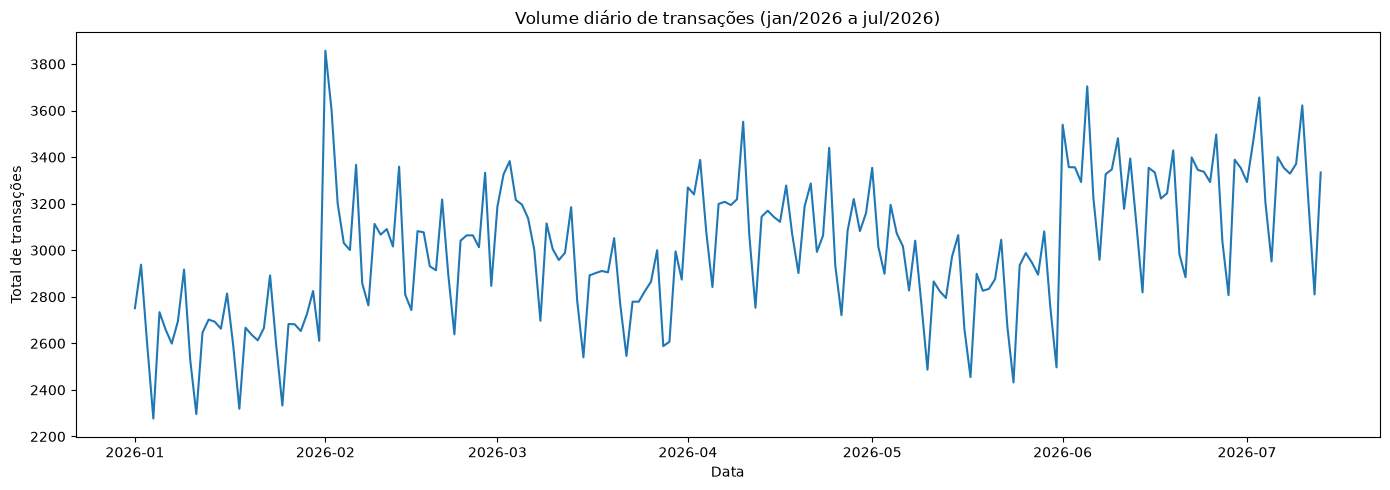

In [189]:
df_taxa_serie_diaria = pd.read_sql(query_taxa_serie_diaria, engine)

plt.figure(figsize=(14, 5))
sns.lineplot(data=df_taxa_serie_diaria, x="data_transacao", y="total_transacoes")
plt.title("Volume diário de transações (jan/2026 a jul/2026)")
plt.xlabel("Data")
plt.ylabel("Total de transações")
plt.tight_layout()
plt.savefig("../imagens/volume_diario_serie_temporal.png")
plt.show()

In [190]:
df_taxa_serie_diaria["dia_indice"] = range(1, len(df_taxa_serie_diaria) + 1)

pg.corr(df_taxa_serie_diaria["dia_indice"], df_taxa_serie_diaria["total_transacoes"])

,n,r,CI95,p_val,BF10,power
pearson,194,0.47295,"[0.36, 0.58]",3.321228e-12,2.524e+09,1.0


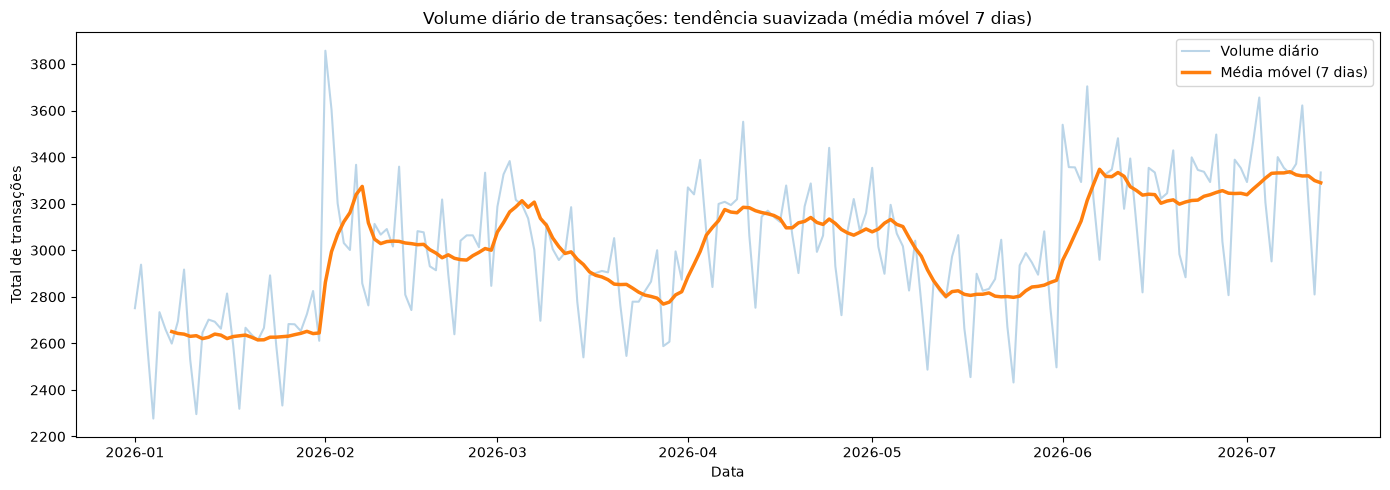

In [191]:
df_taxa_serie_diaria["media_movel_7d"] = df_taxa_serie_diaria["total_transacoes"].rolling(window=7).mean()

plt.figure(figsize=(14, 5))
sns.lineplot(data=df_taxa_serie_diaria, x="data_transacao", y="total_transacoes", alpha=0.3, label="Volume diário")
sns.lineplot(data=df_taxa_serie_diaria, x="data_transacao", y="media_movel_7d", linewidth=2.5, label="Média móvel (7 dias)")
plt.title("Volume diário de transações: tendência suavizada (média móvel 7 dias)")
plt.xlabel("Data")
plt.ylabel("Total de transações")
plt.legend()
plt.tight_layout()
plt.savefig("../imagens/volume_diario_media_movel.png")
plt.show()

### Interpretação

**Fato observado:** o volume oscila em zig-zag regular a cada ~7 dias (efeito de dia da semana já quantificado na 3.1), sobre um nível que parece subir ao longo do período: início de janeiro por volta de 2.600-2.900 transações/dia, final de junho/julho por volta de 3.200-3.800.

**Negócio:** essa é uma leitura visual, ainda não confirmada estatisticamente. A hipótese de negócio (crescimento ligado a novos parceiros trazendo carteira de clientes) será testada a seguir.

### Interpretação

**Inferência estatística:** r = 0,473, IC95% [0,36 – 0,58], p = 3,32e-12 (n=194): o intervalo não cruza o zero, rejeitamos H0 de ausência de correlação entre tempo e volume.

**Tamanho do efeito:** r=0,473 é um efeito moderado a grande pelos padrões de Cohen (~0,10 pequeno, ~0,30 moderado, ~0,50 grande), bem diferente de tudo visto na 3.1 (Cohen's w=0,0522 na 3.1). r² = 0,224: ~22% da variação diária do volume é explicada linearmente pela passagem do tempo.

**Negócio:** confirma que o volume realmente cresce ao longo do período, de forma estatisticamente robusta e com efeito relevante, não apenas "significante por causa do n". Não dá pra confirmar a expectativa de pico de fim de ano, porque os dados não cobrem novembro/dezembro.

### Interpretação

**Fato observado:** a média móvel de 7 dias mostra que a forma não é uma reta suave: é uma sequência de patamares interrompidos por saltos abruptos: baseline ~2.630 em janeiro, salto para ~3.100-3.300 no início de fevereiro, oscila até ~2.800 entre março e maio, e um segundo salto para o patamar mais alto do período (~3.200-3.400) em junho, mantido até 13/julho.

**Inferência estatística:** isso explica por que a correlação de Pearson deu "moderada" (0,473) e não mais alta: Pearson mede relação linear, e essa série é melhor descrita como uma função em degraus. O r capta a direção geral, mas não a forma real do crescimento.

**Negócio:** os saltos abruptos de patamar seriam consistentes com a hipótese de negócio de um parceiro novo trazendo uma carteira de clientes de uma vez, diferente de crescimento orgânico gradual. Essa hipótese é testada diretamente a seguir, com três queries complementares.

### 3.3 Teste da hipótese: crescimento explicado por novos parceiros/estabelecimentos?

A hipótese levantada (crescimento por entrada de parceiros trazendo carteira de estabelecimentos) é testável diretamente nos dados, sem depender de leitura visual do gráfico. Três ângulos complementares:

1. **Quando os estabelecimentos foram cadastrados** (`data_cadastro`): se o degrau de fevereiro fosse causado por um parceiro novo, esperaríamos um pico de cadastros pouco antes.
2. **Quando cada estabelecimento transacionou pela primeira vez** (`MIN(data_transacao)`): mesmo que o cadastro seja antigo, a ativação real (primeira transação) poderia coincidir com o degrau.
3. **De onde vem o volume do mês do degrau**: se em fevereiro a maior parte do volume vier de estabelecimentos cadastrados havia anos, a hipótese não se sustenta.

In [192]:
query_cadastro_mensal = """
SELECT
    DATE_TRUNC('month', data_cadastro) AS mes_cadastro,
    COUNT(*) AS qtd_estabelecimentos
FROM estabelecimentos
GROUP BY DATE_TRUNC('month', data_cadastro)
ORDER BY mes_cadastro;
"""

pd.read_sql(query_cadastro_mensal, engine)

,mes_cadastro,qtd_estabelecimentos
0,2022-01-01 03:00:00+00:00,7
1,2022-02-01 03:00:00+00:00,10
2,2022-03-01 03:00:00+00:00,10
3,2022-04-01 03:00:00+00:00,20
4,2022-05-01 03:00:00+00:00,3
5,2022-06-01 03:00:00+00:00,9
6,2022-07-01 03:00:00+00:00,11
7,2022-08-01 03:00:00+00:00,6
8,2022-09-01 03:00:00+00:00,6
9,2022-10-01 03:00:00+00:00,6


In [193]:
query_primeira_transacao_mensal = """
SELECT
    DATE_TRUNC('month', primeira_transacao) AS mes,
    COUNT(*) AS qtd_estabelecimentos
FROM (
    SELECT
        estabelecimento_id,
        MIN(data_transacao) AS primeira_transacao
    FROM transacoes
    GROUP BY estabelecimento_id
) sub
GROUP BY DATE_TRUNC('month', primeira_transacao)
ORDER BY mes;
"""

pd.read_sql(query_primeira_transacao_mensal, engine)

,mes,qtd_estabelecimentos
0,2026-01-01 03:00:00+00:00,405
1,2026-02-01 03:00:00+00:00,7
2,2026-03-01 03:00:00+00:00,6
3,2026-04-01 03:00:00+00:00,11
4,2026-05-01 03:00:00+00:00,7
5,2026-06-01 03:00:00+00:00,7


In [194]:
query_cadastro_fev = """
SELECT
    DATE_TRUNC('year', e.data_cadastro) AS ano_cadastro,
    COUNT(DISTINCT e.estabelecimento_id) AS qtd_estabelecimentos,
    COUNT(t.transacao_id) AS total_transacoes_fev
FROM transacoes t
JOIN estabelecimentos e
    ON t.estabelecimento_id = e.estabelecimento_id
WHERE DATE_TRUNC('month', t.data_transacao) = '2026-02-01'
GROUP BY DATE_TRUNC('year', e.data_cadastro)
ORDER BY ano_cadastro;
"""

pd.read_sql(query_cadastro_fev, engine)

,ano_cadastro,qtd_estabelecimentos,total_transacoes_fev
0,2022-01-01 03:00:00+00:00,97,21124
1,2023-01-01 03:00:00+00:00,93,20887
2,2024-01-01 03:00:00+00:00,87,17626
3,2025-01-01 03:00:00+00:00,116,24259
4,2026-01-01 03:00:00+00:00,14,2104


### Interpretação

**Fato observado:**
- Teste 1 (`data_cadastro` por mês): sem pico em fevereiro, o mês do degrau mais evidente na série. Houve pico de cadastros entre abril e junho, mas sem um salto de volume proporcional na mesma janela.
- Teste 2 (`MIN(data_transacao)` por estabelecimento, agregado por mês): sem pico de "primeira transação" em fevereiro (apenas 7 estreias). O único pico real é em janeiro (405 estabelecimentos), efeito de borda da janela de dados (o dataset começa em 01/01/2026), não um evento de negócio.
- Teste 3 (composição do volume de fevereiro por ano de cadastro do estabelecimento): das 86.000 transações de fevereiro, 97,6% (83.896 transações, 393 estabelecimentos) vêm de cadastros entre 2022 e 2025, já estabelecidos havia anos. Apenas 2,4% (2.104 transações, 14 estabelecimentos) vêm de cadastros de 2026.

**Negócio:** se a hipótese de novo parceiro trazendo carteira explicasse o degrau de fevereiro, esperaríamos o oposto do Teste 3, uma fatia relevante do volume vindo de cadastros recentes. Os três testes, olhando o problema de ângulos diferentes (quando o estabelecimento foi cadastrado, quando ele começou a transacionar, e de onde vem o volume no mês do degrau), convergem para a mesma resposta.

**Conclusão:** hipótese refutada. Os degraus de volume não são explicados por entrada de novos parceiros ou estabelecimentos. Sem uma causa mercadológica identificável para os saltos, o padrão mais consistente é o de uma base de dados fictícia (gerada sinteticamente, sem uma lógica de negócio real por trás dos degraus). Essa ressalva volta a aparecer nas conclusões finais do notebook, porque muda como qualquer leitura de tendência temporal feita aqui deve ser interpretada.

### Síntese da Seção 3

- Dia da semana não é um fator relevante nem para volume (Cohen's w=0,0522, ponderado pelas ocorrências reais de cada dia) nem para taxa de aprovação (amplitude de 0,17 ponto percentual com a definição corrigida), apesar de tecnicamente "significante" pelo tamanho da amostra.
- Existe uma tendência de crescimento real e estatisticamente robusta ao longo do período (r=0,473), mas ela não é linear: é em degraus, concentrada em dois eventos pontuais (início de fev e junho).
- A hipótese de negócio mais provável para os degraus (entrada de novos parceiros/carteiras de estabelecimentos) foi testada diretamente em três ângulos e refutada: o padrão mais consistente é o de base de dados fictícia, sem lógica de negócio real por trás dos saltos.
- Os dados cobrem só jan-jul/2026, então não é possível confirmar ou refutar a expectativa de pico de fim de ano.

**Resposta à pergunta condutora:** o volume não é estável: há tendência de crescimento real, mas concentrada em saltos discretos, não em um crescimento contínuo suave. A causa desses saltos não pôde ser atribuída a um fator de negócio identificável nos dados disponíveis.

## 4. Concentração de Volume e Estabelecimentos Atípicos

Pergunta condutora: como o volume e a qualidade das transações se distribuem entre os estabelecimentos, individualmente (não mais agregado por dimensão como bandeira ou canal, como nas Seções 2 e 3)? Poucos estabelecimentos concentram a maior parte do volume, ou ele é bem distribuído? Existem estabelecimentos com taxa de aprovação muito fora do padrão? E existem estabelecimentos que nunca chegaram a ativar de fato?

### 4.1 Concentração de Volume (Análise de Pareto)

**Intuição:** o princípio de Pareto (regra 80/20) diz que, em muitos sistemas reais, uma fração pequena das "unidades" (aqui, estabelecimentos) responde pela maior parte do "resultado" (aqui, volume de transações). Isso é comum em negócios B2B/sub-adquirência: poucos clientes grandes, muitos pequenos.

**Como medir:** ordenar os estabelecimentos por volume (do maior para o menor), calcular o percentual acumulado de transações e ver em que ponto esse acumulado cruza 80%. Quantos estabelecimentos (e que % deles) foram necessários pra chegar lá?

In [195]:
query_volume_estabelecimento = """
SELECT
    estabelecimento_id,
    COUNT(*) AS total_transacoes,
    COUNT(*) FILTER (WHERE status_id = 1) AS total_aprovadas,
    ROUND(
        COUNT(*) FILTER (WHERE status_id = 1) * 100.0 / COUNT(*),
        2
    ) AS taxa_aprovacao_pct
FROM transacoes
WHERE status_id IN (1, 2)  -- exclui Cancelada/Estornada
GROUP BY estabelecimento_id
ORDER BY total_transacoes DESC;
"""

df_estabelecimento = pd.read_sql(query_volume_estabelecimento, engine)
df_estabelecimento

,estabelecimento_id,total_transacoes,total_aprovadas,taxa_aprovacao_pct
0,1462,8902,8521,95.72
1,1130,7213,6905,95.73
2,1174,6995,6660,95.21
3,1408,6931,6673,96.28
4,1205,6745,6489,96.20
...,...,...,...,...
438,1193,78,76,97.44
439,1491,50,45,90.00
440,1295,48,47,97.92
441,1357,43,41,95.35


In [196]:
df_estabelecimento["pct_acumulado"] = df_estabelecimento["total_transacoes"].cumsum() / df_estabelecimento["total_transacoes"].sum() * 100
df_estabelecimento["rank_pct"] = (df_estabelecimento.index + 1) / len(df_estabelecimento) * 100

# quantos estabelecimentos (e que % deles) são necessários pra chegar em 80% do volume?
n_80 = (df_estabelecimento["pct_acumulado"] < 80).sum() + 1
print(f"{n_80} estabelecimentos ({n_80 / len(df_estabelecimento) * 100:.1f}% do total) concentram 80% do volume")

df_estabelecimento

201 estabelecimentos (45.4% do total) concentram 80% do volume


,estabelecimento_id,total_transacoes,total_aprovadas,taxa_aprovacao_pct,pct_acumulado,rank_pct
0,1462,8902,8521,95.72,1.547445,0.225734
1,1130,7213,6905,95.73,2.801288,0.451467
2,1174,6995,6660,95.21,4.017237,0.677201
3,1408,6931,6673,96.28,5.222061,0.902935
4,1205,6745,6489,96.20,6.394551,1.128668
...,...,...,...,...,...,...
438,1193,78,76,97.44,99.969406,99.097065
439,1491,50,45,90.00,99.978097,99.322799
440,1295,48,47,97.92,99.986441,99.548533
441,1357,43,41,95.35,99.993916,99.774266


### Interpretação

**Fato observado:** 201 estabelecimentos (45,4% do total de 443) são necessários para concentrar 80% do volume de transações.

**Inferência:** isso é bem diferente do padrão clássico de Pareto (que seria perto de "20% dos estabelecimentos concentram 80% do volume"). Aqui, quase metade dos estabelecimentos é necessária para chegar em 80%, uma concentração real, mas **moderada**, não extrema. Se o volume fosse perfeitamente distribuído entre os 443, seriam necessários exatamente 80% deles (354) para acumular 80% do volume; precisar de só 201 (45,4%) mostra que a distribuição não é uniforme, mas também está longe do "poucos dominam tudo".

**Negócio:** essa diferença é relevante pra estratégia da sub-adquirente. Se fosse 80/20 clássico, a operação dependeria criticamente de um punhado de contas grandes (risco de concentração). Com 45%/80%, a quantidade de transações está mais distribuída entre os estabelecimentos, uma posição de risco mais saudável.

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(df_estabelecimento["rank_pct"], df_estabelecimento["pct_acumulado"], linewidth=2.5, label="Curva de concentração observada")
plt.plot([0, 100], [0, 100], linestyle="--", color="gray", label="Distribuição perfeitamente uniforme")
plt.axhline(80, linestyle=":", color="red", alpha=0.5)
plt.axvline(df_estabelecimento.loc[df_estabelecimento.index < n_80, "rank_pct"].max(), linestyle=":", color="red", alpha=0.5)
plt.title("Curva de Concentração de Volume por Estabelecimento")
plt.xlabel("% acumulado de estabelecimentos (do maior para o menor volume)")
plt.ylabel("% acumulado de transações")
plt.legend()
plt.tight_layout()
plt.savefig("../imagens/concentracao_volume_estabelecimento.png")
plt.show()

### Interpretação

**Fato observado:** a curva fica consistentemente acima da diagonal (distribuição uniforme), cruzando a linha dos 80% de volume perto dos 45% de estabelecimentos, confirmando o número calculado. A curva é suave e gradual, sem um "cotovelo" abrupto logo no início, diferente do formato clássico de Pareto extremo (que sobe quase verticalmente nos primeiros 5-10% e depois achata).

**Negócio:** o maior estabelecimento sozinho representa só 1,5% do volume total. Não há uma "baleia" isolada que, se saísse, quebraria o negócio. Existe concentração real, mas distribuída entre um número razoável de contas de porte médio-alto, não travada em uma ou duas contas críticas.

### 4.2 Perfil dos Estabelecimentos Concentradores

Os 201 estabelecimentos que concentram 80% do volume têm alguma característica em comum (segmento, região, parceiro), ou estão espalhados como o resto da base? Cruzamos o grupo "concentrador" (top 80% do volume) com o "cauda" (demais 20%) contra as dimensões de perfil de `estabelecimentos`.

In [198]:
query_estabelecimentos_dim = """
SELECT
    estabelecimento_id,
    segmento,
    regiao,
    estado,
    parceiro,
    status_estabelecimento
FROM estabelecimentos;
"""

df_dim = pd.read_sql(query_estabelecimentos_dim, engine)

df_estabelecimento_perfil = df_estabelecimento.merge(df_dim, on="estabelecimento_id", how="left")
# Usa n_80 (calculado na 4.1) diretamente, em vez de comparar pct_acumulado <= 80: o corte por
# percentual excluía o estabelecimento que cruza de baixo para cima de 80%, deixando 200 no grupo
# Concentrador em vez dos 201 que a 4.1 calculou.
df_estabelecimento_perfil["grupo"] = np.where(
    np.arange(len(df_estabelecimento_perfil)) < n_80,
    "Concentrador (top 80%)",
    "Cauda (demais 20%)"
)

df_estabelecimento_perfil["grupo"].value_counts()

grupo
Cauda (demais 20%)        242
Concentrador (top 80%)    201
Name: count, dtype: int64

In [199]:
for col in ["segmento", "regiao", "parceiro"]:
    print(f"=== {col} ===")
    tabela = pd.crosstab(
        df_estabelecimento_perfil[col],
        df_estabelecimento_perfil["grupo"],
        normalize="columns"
    ).round(3) * 100
    print(tabela)
    print()

=== segmento ===
grupo         Cauda (demais 20%)  Concentrador (top 80%)
segmento                                                
Alimentação                  6.6                    14.4
Educação                    15.3                     7.0
Eletrônicos                 10.3                     8.0
Farmácia                     4.1                    13.9
Hotelaria                   20.2                     7.5
Saúde                        9.1                     7.5
Serviços                     9.9                     7.0
Supermercado                 6.2                    13.4
Transporte                  11.2                     9.5
Vestuário                    7.0                    11.9

=== regiao ===
grupo         Cauda (demais 20%)  Concentrador (top 80%)
regiao                                                  
Centro-Oeste                14.0                    13.4
Nordeste                    24.4                    22.9
Norte                       11.6                    10.

### Interpretação

**Fato observado (segmento):** três segmentos aparecem bem mais representados entre os concentradores do que na cauda: Farmácia (4,1% → 13,9%, ~3,4x), Alimentação (6,6% → 14,4%, ~2,2x) e Supermercado (6,2% → 13,4%, ~2,2x). No sentido oposto, Hotelaria (20,2% → 7,5%) e Educação (15,3% → 7,0%) estão sobrerrepresentados na cauda. Praticamente idêntico ao padrão de antes da correção do critério de `grupo` (a mudança de 1 estabelecimento em 443 não alterou a leitura).

**Inferência/Negócio:** esse padrão faz sentido de negócio, farmácia, alimentação e supermercado são segmentos de consumo recorrente e frequente, geram mais transações por estabelecimento ao longo de meses. Hotelaria e educação têm ciclos de cobrança mais espaçados (reservas pontuais, mensalidades), então cada estabelecimento gera menos transações no mesmo período.

**Fato observado (região):** a maior diferença entre os dois grupos é Sudeste (31,0% na cauda contra 34,3% no concentrador, ~3,3 pontos); as demais regiões ficam abaixo de 1,6 ponto de diferença. **Negócio:** região não explica a concentração de forma relevante.

**Parceiro:** a maior diferença é Parceiro Beta (16,5% contra 18,4%, ~1,9 ponto); os demais ficam abaixo disso. Nenhum parceiro se destaca, a concentração de volume não está ligada a qual parceiro trouxe o estabelecimento.

In [200]:
resultados_perfil = []

for col in ["segmento", "regiao", "parceiro"]:
    tabela_contagem = pd.crosstab(df_estabelecimento_perfil[col], df_estabelecimento_perfil["grupo"])
    chi2, p, dof, esperado = chi2_contingency(tabela_contagem)
    n = tabela_contagem.values.sum()
    cramer_v = np.sqrt(chi2 / (n * (min(tabela_contagem.shape) - 1)))
    resultados_perfil.append({
        "dimensao": col,
        "chi2": round(chi2, 2),
        "p_valor": p,
        "cramer_v": round(cramer_v, 4)
    })

pd.DataFrame(resultados_perfil)

,dimensao,chi2,p_valor,cramer_v
0,segmento,49.29,1.463770e-07,0.3336
1,regiao,0.78,9.404813e-01,0.0421
2,parceiro,0.42,9.946558e-01,0.0309


### Interpretação

**Fato observado:** segmento tem χ²=49,29, p=1,46e-07 e Cramér's V=0,3336. Região tem χ²=0,78, p=0,94, V=0,0421 (desprezível). Parceiro tem χ²=0,42, p=0,995, V=0,0309 (desprezível). Muito próximo dos valores de antes da correção (χ²=48,36, V=0,3304 para segmento), a mudança de 1 estabelecimento de grupo não alterou a conclusão.

**Inferência estatística:** diferente de quase todos os qui-quadrados da Seção 2 (onde n=583 mil tornava quase tudo "significante" mesmo com efeito desprezível), aqui com n=443 o padrão é limpo: segmento é significativo **e** tem efeito moderado a forte (V=0,3336 é um dos maiores Cramér's V do projeto); região e parceiro não são significativos e têm efeito desprezível.

**Negócio:** a concentração de volume por estabelecimento está genuinamente ligada ao segmento de atuação, não à região geográfica nem a qual parceiro trouxe o cliente. É um dos achados de maior efeito de tamanho do projeto, forte o suficiente para pesar de fato nas decisões de negócio, não só nos números.

### 4.3 Taxa de Aprovação Atípica por Estabelecimento

**Intuição:** ordenar `df_estabelecimento` por `taxa_aprovacao_pct` e olhar os extremos tem um problema, estabelecimentos com poucas transações têm taxas instáveis por acaso (mesmo efeito visto na Seção 2 com o horário de madrugada).

**Conceito técnico:** o jeito certo de comparar taxas entre grupos de tamanhos muito diferentes é o **funnel plot** (gráfico de funil): no eixo X o volume (n), no eixo Y a taxa de aprovação, com a régua geral como referência. Como a variância de uma proporção cai com o tamanho da amostra (erro padrão = √(p·(1-p)/n)), esperamos ver os pontos formando um funil, muita dispersão em baixo volume, pouca dispersão em alto volume. Os pontos que importam são os que fogem da régua **apesar de** terem volume alto.

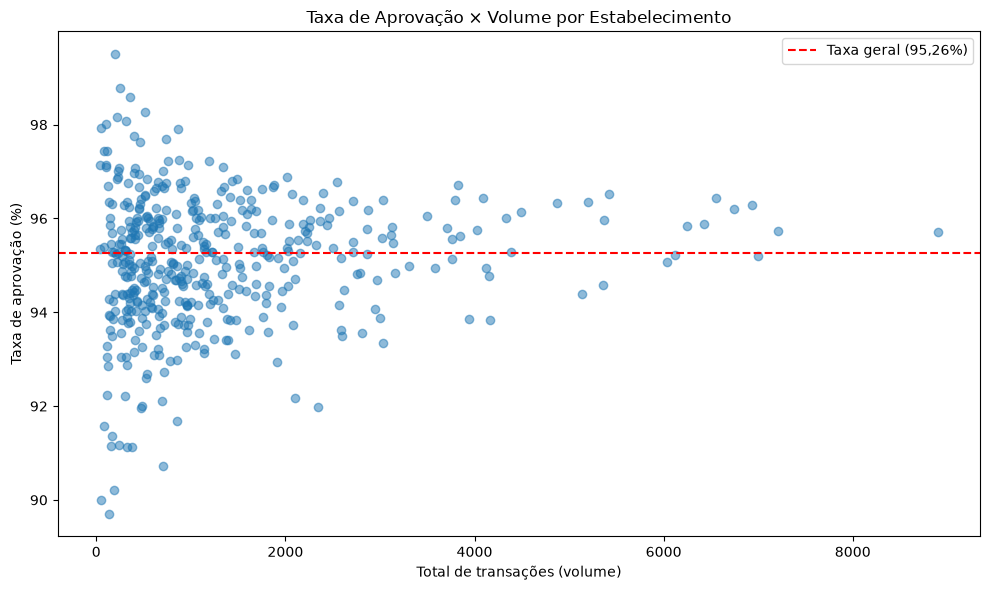

In [201]:
plt.figure(figsize=(10, 6))
plt.scatter(df_estabelecimento["total_transacoes"], df_estabelecimento["taxa_aprovacao_pct"], alpha=0.5)
plt.axhline(95.26, color="red", linestyle="--", label="Taxa geral (95,26%)")
plt.title("Taxa de Aprovação × Volume por Estabelecimento")
plt.xlabel("Total de transações (volume)")
plt.ylabel("Taxa de aprovação (%)")
plt.legend()
plt.tight_layout()
plt.savefig("../imagens/taxa_aprovacao_vs_volume_estabelecimento.png")
plt.show()

### Interpretação

**Fato observado:** o formato de funil aparece nitidamente. Em baixo volume (<1.000 transações), a taxa varia de ~90% a ~99%. Conforme o volume cresce, os pontos convergem para perto da régua de 95,26%.

**Inferência:** esse é o padrão esperado por acaso estatístico, não evidência de que estabelecimentos pequenos aprovam melhor ou pior de verdade. Precisamos formalizar quais pontos estão de fato fora do esperado, ajustando pelo volume de cada um.

**Conceito técnico:** calculamos um z-score ajustado por n, para cada estabelecimento, o erro padrão esperado é √(p·(1-p)/n) (p = taxa geral). O z-score é (taxa_observada − taxa_geral) / erro_padrão. Um z-score de ±3 significa "essa taxa está a 3 erros-padrão do que o acaso explicaria", um desvio real, não ruído.

In [202]:
p_geral = 95.26 / 100
n = df_estabelecimento["total_transacoes"]
erro_padrao_pct = np.sqrt(p_geral * (1 - p_geral) / n) * 100

df_estabelecimento["z_score"] = (df_estabelecimento["taxa_aprovacao_pct"] - 95.26) / erro_padrao_pct

df_atipicos = df_estabelecimento[df_estabelecimento["z_score"].abs() > 3].sort_values("z_score")
df_atipicos

,estabelecimento_id,total_transacoes,total_aprovadas,taxa_aprovacao_pct,pct_acumulado,rank_pct,z_score
66,1354,2348,2160,91.99,45.358796,15.124153,-7.456797
78,1233,2098,1934,92.18,49.940811,17.832957,-6.639097
250,1250,701,636,90.73,87.297639,56.659142,-5.644335
38,1092,3034,2832,93.34,32.317986,8.803612,-4.976965
224,1447,854,783,91.69,83.844136,50.790068,-4.909674
92,1065,1909,1774,92.93,54.829811,20.993228,-4.790870
19,1258,4166,3909,93.83,20.324160,4.514673,-4.343614
47,1398,2806,2625,93.55,36.904346,10.835214,-4.262805
54,1114,2598,2429,93.49,40.191492,12.415350,-4.245691
24,1480,3938,3696,93.85,23.858147,5.643341,-4.164017


### Interpretação

**Fato observado:** cerca de 48 estabelecimentos romperam o limite de |z| > 3, 32 do lado negativo (taxa abaixo do esperado, z de -7,46 a -3,02) e 16 do lado positivo (taxa acima do esperado, z de 3,12 a 4,46). Vários dos maiores estabelecimentos da base estão no grupo positivo (ex.: id 1408, 6.931 transações, 96,28%, z=4,00), pontos que no gráfico visual pareciam "grudados na régua".

**Inferência estatística:** com n de milhares, o erro padrão esperado é minúsculo (<0,5 ponto percentual), então um desvio de 1 a 1,5 ponto (visualmente pequeno) já é estatisticamente extremo. Com 443 testes e corte |z|>3, o acaso puro explicaria só ~1-2 casos; termos ~48 é quase 25x mais que o esperado, evidência forte de heterogeneidade real de taxa de aprovação entre estabelecimentos.

**Negócio:** se segmento já explica concentração de volume (4.2), é plausível que também explique parte dessa variação de taxa. Testamos isso a seguir.

In [203]:
p_geral = 95.26 / 100
n = df_estabelecimento_perfil["total_transacoes"]
erro_padrao_pct = np.sqrt(p_geral * (1 - p_geral) / n) * 100
df_estabelecimento_perfil["z_score"] = (df_estabelecimento_perfil["taxa_aprovacao_pct"] - 95.26) / erro_padrao_pct

df_estabelecimento_perfil["status_taxa"] = np.select(
    [df_estabelecimento_perfil["z_score"] > 3, df_estabelecimento_perfil["z_score"] < -3],
    ["Atípico alto", "Atípico baixo"],
    default="Normal"
)

print(df_estabelecimento_perfil["status_taxa"].value_counts())
print()
pd.crosstab(df_estabelecimento_perfil["segmento"], df_estabelecimento_perfil["status_taxa"])

status_taxa
Normal           395
Atípico baixo     32
Atípico alto      16
Name: count, dtype: int64



status_taxa,Atípico alto,Atípico baixo,Normal
segmento,,,
Alimentação,3,0,42
Educação,0,2,49
Eletrônicos,0,11,30
Farmácia,3,0,35
Hotelaria,0,12,52
Saúde,0,4,33
Serviços,0,0,38
Supermercado,3,0,39
Transporte,7,0,39


### Interpretação

**Fato observado:** o padrão é quase perfeitamente segregado por segmento. "Atípico alto" aparece só em 4 segmentos: Alimentação (3), Farmácia (3), Supermercado (3) e Transporte (7), 16 casos. "Atípico baixo" aparece só em outros 5: Educação (2), Eletrônicos (11), Hotelaria (12), Saúde (4) e Vestuário (3), 32 casos. Serviços não tem nenhum atípico. Nenhum segmento tem casos nos dois lados ao mesmo tempo. Teste de qui-quadrado confirma: χ²=84,38, p=1,45e-10, Cramér's V=0,3086 (segundo maior efeito do projeto). Ressalva técnica: ~67% das células têm frequência esperada abaixo de 5 (vários segmentos com zero de um lado), o que pede cautela com o p-valor exato, mas não muda a leitura qualitativa, a segregação é nítida demais para depender desse detalhe.

**Negócio:** os dois grupos fazem sentido: **aprovam mais que o esperado**, Alimentação, Farmácia, Supermercado, Transporte (consumo de rotina, tipicamente presencial/POS, menor risco). **Aprovam menos que o esperado**, Educação, Eletrônicos, Hotelaria, Saúde, Vestuário (tickets mais altos, mais sujeitos a análise de crédito ou canais *card-not-present*). A taxa de aprovação "atípica" por estabelecimento não é um problema operacional espalhado ao acaso, é estrutural e explicada por segmento.

### 4.4 Estabelecimentos Não Ativados

500 estabelecimentos cadastrados, mas só 443 aparecem em `df_estabelecimento` (transacionaram no período). Os 500 - 443 = 57 restantes nunca transacionaram durante a janela observada. Isso tem explicação de negócio (ex.: status "Bloqueado"/"Inativo", esperado), ou boa parte está "Liberado"/"Pendente" mas mesmo assim nunca transacionou?

In [204]:
query_estabelecimentos_sem_transacao = """
SELECT
    status_estabelecimento,
    COUNT(*) AS qtd_estabelecimentos
FROM estabelecimentos
WHERE estabelecimento_id NOT IN (
    SELECT DISTINCT estabelecimento_id FROM transacoes
)
GROUP BY status_estabelecimento
ORDER BY qtd_estabelecimentos DESC;
"""

pd.read_sql(query_estabelecimentos_sem_transacao, engine)

,status_estabelecimento,qtd_estabelecimentos
0,Pendente,50
1,Bloqueado,4
2,Inativo,3


Pelo menos 50 dos 57 (87,7%) estão com status "Pendente", uma explicação plausível para a maioria (ainda não foi liberado pra operar). Mas isso não fecha a pergunta: "Pendente" pode ser recente (normal) ou pendente há meses (atenção real). Para separar isso, cruzamos com o tempo desde o cadastro (`data_cadastro`): cadastro ≤ 30 dias sem transação é esperado (ainda em onboarding); > 30 dias sem transação é sinal de atenção.

In [205]:
query_estabelecimentos_sem_transacao = """
SELECT
    estabelecimento_id,
    status_estabelecimento,
    data_cadastro,
    DATE '2026-07-13' - data_cadastro AS dias_desde_cadastro
FROM estabelecimentos
WHERE estabelecimento_id NOT IN (
    SELECT DISTINCT estabelecimento_id FROM transacoes
)
ORDER BY dias_desde_cadastro;
"""

df_sem_transacao = pd.read_sql(query_estabelecimentos_sem_transacao, engine)
df_sem_transacao["situacao"] = np.where(
    df_sem_transacao["dias_desde_cadastro"] <= 30,
    "Cadastro recente (≤30 dias)",
    "Cadastro antigo (>30 dias) - atenção"
)

df_sem_transacao

,estabelecimento_id,status_estabelecimento,data_cadastro,dias_desde_cadastro,situacao
0,1195,Pendente,2026-06-30,13,Cadastro recente (≤30 dias)
1,1243,Pendente,2026-06-29,14,Cadastro recente (≤30 dias)
2,1437,Pendente,2026-06-29,14,Cadastro recente (≤30 dias)
3,1405,Pendente,2026-06-28,15,Cadastro recente (≤30 dias)
4,1276,Pendente,2026-06-26,17,Cadastro recente (≤30 dias)
5,1198,Pendente,2026-06-26,17,Cadastro recente (≤30 dias)
6,1232,Pendente,2026-06-25,18,Cadastro recente (≤30 dias)
7,1351,Pendente,2026-06-24,19,Cadastro recente (≤30 dias)
8,1421,Pendente,2026-06-24,19,Cadastro recente (≤30 dias)
9,1200,Bloqueado,2026-06-24,19,Cadastro recente (≤30 dias)


In [206]:
df_sem_transacao.groupby(["situacao", "status_estabelecimento"]).size().unstack(fill_value=0)

status_estabelecimento,Bloqueado,Inativo,Pendente
situacao,,,
Cadastro antigo (>30 dias) - atenção,3,3,39
Cadastro recente (≤30 dias),1,0,11


**Fato observado:** dos 57, 45 (79%) são "cadastro antigo (>30 dias)", 39 Pendente, 3 Bloqueado, 3 Inativo; só 12 são "cadastro recente".

### Nota metodológica: recorte temporal no cálculo de faturamento

Uma primeira tentativa de medir "faturamento nos primeiros 30 dias após o cadastro" (para checar se algum estabelecimento ativou, mas com faturamento muito baixo) esbarrou num problema: a tabela `transacoes` só tem dados a partir de 01/01/2026, mas o cálculo original não limitava `data_cadastro`, incluindo estabelecimentos cadastrados em 2022-2025. Para esses, "os 30 dias depois do cadastro" caem em anos sem nenhum dado na tabela `transacoes`, `faturamento_30d = 0` nesse caso não significa "faturou pouco", significa "não temos dado daquele período". Isso gerou 432 falsos positivos na primeira tentativa. A correção: só avaliar estabelecimentos cadastrados dentro da própria janela de dados observável (`data_cadastro` entre 01/01/2026 e 13/06/2026, garantindo também uma janela de 30 dias completa).

In [207]:
query_faturamento_30d = """
SELECT
    e.estabelecimento_id,
    e.status_estabelecimento,
    e.data_cadastro,
    COUNT(t.transacao_id) AS qtd_transacoes_30d,
    COALESCE(SUM(t.valor_bruto), 0) AS faturamento_30d
FROM estabelecimentos e
LEFT JOIN transacoes t
    ON t.estabelecimento_id = e.estabelecimento_id
    AND t.data_transacao BETWEEN e.data_cadastro AND e.data_cadastro + INTERVAL '30 days'
WHERE e.data_cadastro BETWEEN DATE '2026-01-01' AND DATE '2026-07-13' - INTERVAL '30 days'
GROUP BY e.estabelecimento_id, e.status_estabelecimento, e.data_cadastro
HAVING COALESCE(SUM(t.valor_bruto), 0) < 100
ORDER BY faturamento_30d DESC;
"""

df_faturamento_baixo_30d = pd.read_sql(query_faturamento_30d, engine)
df_faturamento_baixo_30d

,estabelecimento_id,status_estabelecimento,data_cadastro,qtd_transacoes_30d,faturamento_30d
0,1158,Pendente,2026-06-03,0,0.0
1,1009,Pendente,2026-05-23,0,0.0
2,1453,Pendente,2026-04-04,0,0.0
3,1108,Pendente,2026-04-29,0,0.0
4,1050,Inativo,2026-05-20,0,0.0
5,1375,Pendente,2026-05-28,0,0.0
6,1234,Pendente,2026-04-05,0,0.0
7,1071,Pendente,2026-04-14,0,0.0
8,1224,Pendente,2026-05-16,0,0.0
9,1056,Pendente,2026-05-12,0,0.0


In [208]:
print("Total de linhas:", len(df_faturamento_baixo_30d))
print(df_faturamento_baixo_30d["qtd_transacoes_30d"].value_counts())

Total de linhas: 45
qtd_transacoes_30d
0    45
Name: count, dtype: int64


**Fato observado:** com o recorte corrigido, restam 45 linhas, 100% delas com `qtd_transacoes_30d = 0`. Não existe nenhum caso de "ativou, mas com faturamento fraco", é binário: zero transação completa, ou (fora dessa lista) faturamento ≥ R$100.

**Inferência:** essa lista de 45, obtida por um caminho de query diferente, é a mesma população dos 45 "cadastro antigo" identificados acima, dois caminhos convergindo no mesmo grupo é um bom sinal de triangulação, reforça que o achado é real.

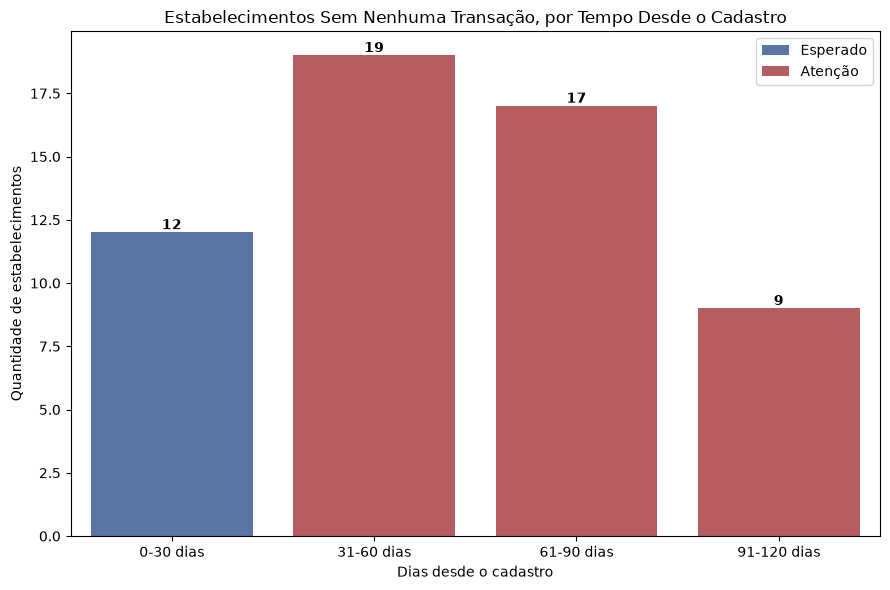

In [209]:
faixas = pd.cut(
    df_sem_transacao["dias_desde_cadastro"],
    bins=[0, 30, 60, 90, 120],
    labels=["0-30 dias", "31-60 dias", "61-90 dias", "91-120 dias"]
)
df_faixas = faixas.value_counts().sort_index().reset_index()
df_faixas.columns = ["faixa", "qtd_estabelecimentos"]
df_faixas["status"] = np.where(df_faixas["faixa"] == "0-30 dias", "Esperado", "Atenção")

cor_esperado = "#4C72B0"
cor_atencao = "#C44E52"

plt.figure(figsize=(9, 6))
ax = sns.barplot(
    data=df_faixas,
    x="faixa",
    y="qtd_estabelecimentos",
    hue="status",
    palette={"Esperado": cor_esperado, "Atenção": cor_atencao},
    dodge=False
)
for container in ax.containers:
    ax.bar_label(container, fontweight="bold")

plt.title("Estabelecimentos Sem Nenhuma Transação, por Tempo Desde o Cadastro")
plt.xlabel("Dias desde o cadastro")
plt.ylabel("Quantidade de estabelecimentos")
plt.legend(title="")
plt.tight_layout()
plt.savefig("../imagens/nao_ativados_por_tempo.png", dpi=150)
plt.show()

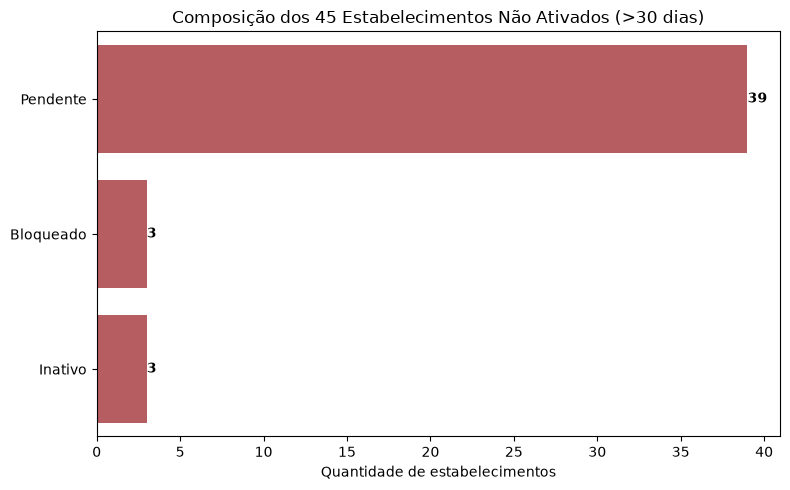

In [210]:
contagem_status_antigo = (
    df_sem_transacao[df_sem_transacao["situacao"].str.contains("atenção")]["status_estabelecimento"]
    .value_counts()
    .reset_index()
)
contagem_status_antigo.columns = ["status_estabelecimento", "qtd_estabelecimentos"]

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=contagem_status_antigo,
    y="status_estabelecimento",
    x="qtd_estabelecimentos",
    color=cor_atencao
)
ax.bar_label(ax.containers[0], fontweight="bold")

plt.title("Composição dos 45 Estabelecimentos Não Ativados (>30 dias)")
plt.xlabel("Quantidade de estabelecimentos")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../imagens/nao_ativados_composicao_status.png", dpi=150)
plt.show()

### Interpretação

**Fato observado:** dos 57 estabelecimentos sem nenhuma transação, 45 (79%) já passaram de 30 dias desde o cadastro, chegando a até 120 dias, e a distribuição entre as faixas (19 entre 31-60 dias, 17 entre 61-90, 9 entre 91-120) é praticamente constante, não é um problema que se resolve com o tempo. Desses 45, 39 (87%) seguem com status "Pendente"; só 6 têm status que justificaria a ausência de transação (Bloqueado ou Inativo).

**Negócio:** o achado real não é "baixo faturamento" (essa hipótese foi testada e não se confirmou como categoria própria, o resultado é binário: zero ou normal), é **não ativação prolongada**. 39 estabelecimentos com aprovação pendente há mais de um mês, alguns há quase 4 meses, sugerem um funil de ativação travado, seja por falha de processo, seja por característica da geração sintética da base. De qualquer forma, é uma lista concreta e acionável (pelo `estabelecimento_id`) para o time responsável validar.

### Síntese da Seção 4

- **Concentração de volume:** existe concentração real, mas moderada, 45,4% dos estabelecimentos concentram 80% do volume (não o padrão 80/20 clássico). Nenhuma conta isolada domina (a maior representa só 1,5% do total).
- **Perfil dos concentradores:** a concentração é explicada por segmento (Cramér's V=0,3336), não por região nem parceiro. Segmentos de consumo recorrente (Farmácia, Alimentação, Supermercado) concentram volume; segmentos de ciclo mais espaçado (Hotelaria, Educação) não.
- **Taxa de aprovação atípica:** ~48 estabelecimentos (11%) têm taxa de aprovação estatisticamente atípica (|z|>3), incluindo estabelecimentos de alto volume que pareciam "normais" a olho nu. Essa variação também é explicada por segmento (χ²=84,38, V=0,3086): os mesmos segmentos de consumo recorrente aprovam mais; os de ticket mais alto/*card-not-present* aprovam menos.
- **Estabelecimentos não ativados:** 45 dos 500 estabelecimentos cadastrados (9%) nunca transacionaram apesar de mais de 30 dias (até 120) desde o cadastro; desses, 39 seguem em status "Pendente" (o grupo prioritário para investigação de ativação travada) e 6 já têm status Bloqueado/Inativo, que explica a ausência de transação. Não existe uma categoria intermediária de "ativação fraca" por faturamento, é binário.

**Resposta à pergunta condutora:** o volume e a qualidade das transações não se distribuem uniformemente entre os estabelecimentos, mas a explicação estrutural para ambos é a mesma: **segmento de atuação**, não geografia, não parceiro comercial. Separadamente, existe um grupo concreto e acionável de 39 estabelecimentos (dos 45 sem transação há mais de 30 dias) com ativação aparentemente travada, sem explicação de negócio nos dados disponíveis (consistente com a hipótese de base fictícia levantada na Seção 3); os outros 6 já têm status que justifica a ausência de transação.

## 5. Data Leakage

### Pergunta condutora

Quais colunas da tabela `transacoes` só existem por causa do resultado da transação, e por isso não podem entrar como feature em um modelo que tente prever esse mesmo resultado (`status_id`/aprovação)?

### Por que importa

Um modelo treinado com uma coluna vazada aprende a colar no resultado em vez de aprender o padrão que antecede a decisão. Em desenvolvimento isso aparece como acurácia artificialmente alta (98%, 99%); em produção o modelo falha, porque no momento real da previsão essas colunas ainda não existem ou estão vazias. O critério usado em toda a checagem desta seção é sempre o mesmo: essa informação estaria disponível no momento em que o modelo precisa decidir, antes de a transação ser processada?

### 5.1 Colunas já sinalizadas na Seção 1

- `codigo_autorizacao` e `txid_pix` só são preenchidos depois que a adquirente ou o Banco Central autoriza a transação. Antes da decisão, os dois campos simplesmente não existem.
- `motivo_negativa_id` tem o valor 0 como sentinela de "não se aplica" (Seção 1); qualquer valor diferente de 0 só é atribuído depois que a transação já foi negada. A coluna é, por definição, uma codificação do resultado.

As duas checagens a seguir testam as demais colunas numéricas da tabela, que ainda não tinham sido avaliadas sob esse critério.

### 5.2 valor_taxa e valor_liquido: proxy perfeito

In [211]:
query_leakage_numerico = """
SELECT
    status_id,
    COUNT(*) AS total,
    COUNT(*) FILTER (WHERE valor_taxa IS NULL) AS nulos_valor_taxa,
    COUNT(*) FILTER (WHERE valor_liquido IS NULL) AS nulos_valor_liquido,
    COUNT(*) FILTER (WHERE tempo_processamento_ms IS NULL) AS nulos_tempo_processamento,
    ROUND(AVG(valor_taxa), 2) AS media_valor_taxa,
    ROUND(AVG(valor_liquido), 2) AS media_valor_liquido,
    ROUND(AVG(tempo_processamento_ms), 2) AS media_tempo_processamento_ms
FROM transacoes
GROUP BY status_id
ORDER BY status_id;
"""

df_leakage_numerico = pd.read_sql(query_leakage_numerico, engine)
df_leakage_numerico

,status_id,total,nulos_valor_taxa,nulos_valor_liquido,nulos_tempo_processamento,media_valor_taxa,media_valor_liquido,media_tempo_processamento_ms
0,1,548006,0,0,0,15.23,507.53,739.40
1,2,27265,0,0,0,0.00,0.00,989.26
2,3,4987,0,0,0,0.00,0.00,802.21
3,4,2742,0,0,0,0.00,0.00,811.89


**Fato observado:** nas 583.000 transações, `valor_taxa`, `valor_liquido` e `tempo_processamento_ms` nunca são nulos (zero nulos nas quatro categorias de status). Mas a média de `valor_taxa` e `valor_liquido` só é diferente de zero em Aprovada (status_id=1), R$15,23 e R$507,53 respectivamente. Negada, Cancelada e Estornada têm média exatamente 0,00 nos dois casos.

**Inferência:** média exatamente 0,00, não "próxima de zero", é sinal de que não é variação natural, é um valor fixo atribuído a quem não foi aprovado. Mesma lógica de sentinela já documentada em `motivo_negativa_id` na Seção 1: aqui zero não significa "não medido", significa "não se aplica porque a transação não foi aprovada".

In [212]:
query_confirma_leakage = """
SELECT
    status_id,
    COUNT(*) FILTER (WHERE valor_taxa > 0) AS qtd_valor_taxa_positivo,
    COUNT(*) FILTER (WHERE valor_liquido > 0) AS qtd_valor_liquido_positivo,
    MAX(valor_taxa) AS max_valor_taxa,
    MAX(valor_liquido) AS max_valor_liquido
FROM transacoes
GROUP BY status_id
ORDER BY status_id;
"""

pd.read_sql(query_confirma_leakage, engine)

,status_id,qtd_valor_taxa_positivo,qtd_valor_liquido_positivo,max_valor_taxa,max_valor_liquido
0,1,548006,548006,1177.76,19788.0
1,2,0,0,0.00,0.0
2,3,0,0,0.00,0.0
3,4,0,0,0.00,0.0


**Fato observado:** confirmando a suspeita, 100% das 548.006 transações Aprovadas têm `valor_taxa` e `valor_liquido` maiores que zero. Nas outras três categorias (Negada, Cancelada, Estornada, 34.994 transações no total) nenhuma linha tem valor positivo em nenhuma das duas colunas.

**Inferência:** essa é uma separação perfeita, 100% contra 0%, não uma correlação forte. Um modelo que recebesse `valor_taxa` ou `valor_liquido` como feature não precisaria aprender nada sobre o padrão da transação, bastaria checar se o valor é maior que zero. É a definição prática de vazamento: a coluna é gerada como consequência direta da aprovação (o sistema só calcula a taxa cobrada e o valor líquido depois de decidir aprovar), não como algo que antecede ou influencia essa decisão.

**Negócio:** faz sentido também pelo lado de negócio, taxa e valor líquido só existem quando existe uma transação aprovada para cobrar taxa sobre. Não é um bug de sistema, é a própria área de risco/produto confirmando o resultado dentro do dado.

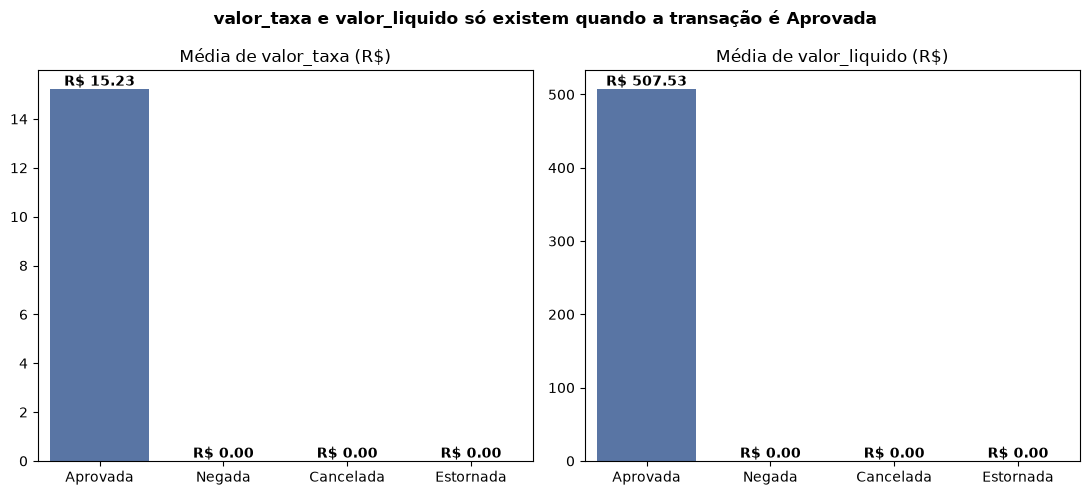

In [213]:
status_labels = {1: "Aprovada", 2: "Negada", 3: "Cancelada", 4: "Estornada"}
df_leakage_numerico["status"] = df_leakage_numerico["status_id"].map(status_labels)

cor_neutra = "#4C72B0"
ordem_status = list(status_labels.values())

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, col, titulo in zip(
    axes,
    ["media_valor_taxa", "media_valor_liquido"],
    ["Média de valor_taxa (R$)", "Média de valor_liquido (R$)"],
):
    sns.barplot(data=df_leakage_numerico, x="status", y=col, order=ordem_status, color=cor_neutra, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel("")
    for container in ax.containers:
        ax.bar_label(container, fmt="R$ %.2f", fontweight="bold")

plt.suptitle("valor_taxa e valor_liquido só existem quando a transação é Aprovada", fontweight="bold")
plt.tight_layout()
plt.savefig("../imagens/leakage_valor_taxa_liquido.png", dpi=150)
plt.show()

### 5.3 tempo_processamento_ms: um vazamento mais sutil

In [214]:
query_tempo_processamento = """
SELECT
    status_id,
    COUNT(*) AS total,
    ROUND(AVG(tempo_processamento_ms), 2) AS media,
    ROUND(STDDEV(tempo_processamento_ms), 2) AS desvio_padrao
FROM transacoes
GROUP BY status_id
ORDER BY status_id;
"""

df_tempo_processamento = pd.read_sql(query_tempo_processamento, engine)
df_tempo_processamento

,status_id,total,media,desvio_padrao
0,1,548006,739.40,288.83
1,2,27265,989.26,296.03
2,3,4987,802.21,301.08
3,4,2742,811.89,294.64


**Fato observado:** tempo médio de processamento é 739,40ms para Aprovada (n=548.006, desvio padrão 288,83) contra 989,26ms para Negada (n=27.265, desvio padrão 296,03), quase 250ms de diferença. Cancelada (802,21ms) e Estornada (811,89ms) ficam entre os dois extremos, mais perto de Aprovada.

**Inferência estatística:** Cohen's d entre Aprovada e Negada = 0,86, efeito grande pelos limiares de Cohen (~0,2 pequeno, ~0,5 médio, ~0,8 grande).

**Conceito técnico:** esse vazamento é de um tipo diferente dos dois anteriores. `valor_taxa` e `valor_liquido` vazam porque são gerados depois da decisão, como consequência dela. `tempo_processamento_ms` vaza porque é gerado durante o processo que leva à decisão, provavelmente porque negar uma transação envolve passos extras de checagem (validação de crédito, análise de risco) que uma aprovação direta não precisa. O valor final da coluna só fica disponível quando o processamento inteiro, incluindo a decisão, já terminou.

**Negócio:** diferente de `valor_taxa`/`valor_liquido` (separação perfeita, fácil de notar até visualmente), esse tipo de vazamento é mais perigoso na prática, as distribuições se sobrepõem em vez de serem 100%/0%, então é fácil incluir a coluna achando que é um padrão real de comportamento em vez de um efeito do próprio processo de decisão.

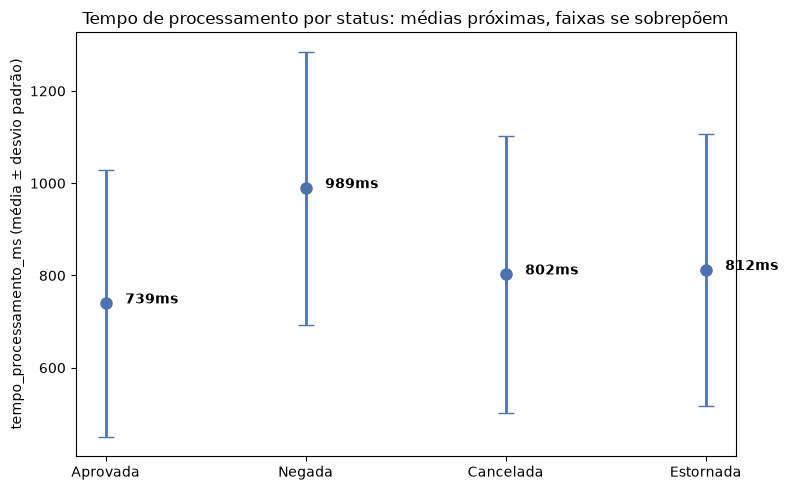

In [215]:
df_tempo_processamento["status"] = df_tempo_processamento["status_id"].map(status_labels)

plt.figure(figsize=(8, 5))
plt.errorbar(
    df_tempo_processamento["status"],
    df_tempo_processamento["media"],
    yerr=df_tempo_processamento["desvio_padrao"],
    fmt="o",
    color=cor_neutra,
    ecolor=cor_neutra,
    elinewidth=2,
    capsize=6,
    markersize=8,
)
for x, y in zip(df_tempo_processamento["status"], df_tempo_processamento["media"]):
    plt.annotate(f"{y:.0f}ms", (x, y), textcoords="offset points", xytext=(14, 0), fontweight="bold")

plt.title("Tempo de processamento por status: médias próximas, faixas se sobrepõem")
plt.ylabel("tempo_processamento_ms (média ± desvio padrão)")
plt.xlabel("")
plt.tight_layout()
plt.savefig("../imagens/leakage_tempo_processamento.png", dpi=150)
plt.show()

### Síntese da Seção 5

| Coluna | Tipo de vazamento | Evidência |
|---|---|---|
| `codigo_autorizacao` | Consequência da aprovação | só é preenchido depois de autorizar (Seção 1) |
| `txid_pix` | Consequência da aprovação | mesmo padrão, para PIX (Seção 1) |
| `motivo_negativa_id` | Codificação direta do resultado | só é diferente de 0 quando a transação já foi negada (Seção 1) |
| `valor_taxa` | Consequência da aprovação | separação perfeita, positivo em 100% de Aprovada e 0% do resto |
| `valor_liquido` | Consequência da aprovação | mesma separação perfeita de `valor_taxa` |
| `tempo_processamento_ms` | Gerado durante o processo de decisão | Cohen's d=0,86 entre Aprovada e Negada, efeito grande |

**Resposta à pergunta condutora:** seis colunas são vazamento e precisam sair do conjunto de features de qualquer modelo que tente prever `status_id`/aprovação. Três (`codigo_autorizacao`, `txid_pix`, `motivo_negativa_id`) vazam por estrutura, o próprio esquema do banco só as preenche depois do resultado. Duas (`valor_taxa`, `valor_liquido`) vazam por definição de negócio, são consequências financeiras da aprovação. Uma (`tempo_processamento_ms`) vaza de forma mais sutil, por ser gerada durante o próprio processo de decisão, e é a que mais merece atenção na etapa de Feature Engineering, porque não seria óbvia numa checagem rápida de distribuição.

## 6. Conclusões de Negócio e Validações Finais

### Pergunta condutora

Juntando tudo que foi encontrado nas Seções 1 a 5, quais conclusões têm sustentação estatística suficiente para virar recomendação de negócio? E o achado mais forte do projeto (segmento como fator estrutural de taxa de aprovação, Seção 4) se sustenta quando testado de um jeito diferente, ou quando controlado por outras variáveis que poderiam estar confundindo o resultado?

### 6.1 Validações de robustez sobre o achado mais forte do projeto

Na Seção 4 o efeito de segmento foi medido de forma categórica (top 80% de volume contra cauda; atípico contra normal), com Cramér's V. Ficaram duas perguntas em aberto: um teste que usa a variável contínua diretamente, sem transformá-la em categoria, mostra um efeito parecido? E esse efeito se sustenta se relaxarmos os pressupostos estatísticos da ANOVA?

**Conceito técnico:** ANOVA testa diretamente se a média de uma variável contínua (aqui, `taxa_aprovacao_pct` e `total_transacoes`, por estabelecimento) difere entre os grupos de uma categórica (`segmento`), sem precisar binarizar a variável contínua como fizemos na Seção 4. É um teste mais direto e, em geral, mais poderoso.

In [216]:
aov_taxa = pg.anova(data=df_estabelecimento_perfil, dv="taxa_aprovacao_pct", between="segmento", detailed=True)
aov_taxa

,Source,SS,DF,MS,F,p_unc,np2
0,segmento,300.912762,9,33.434751,26.025002,7.773086e-36,0.351044
1,Within,556.282265,433,1.284717,NaN,NaN,NaN


In [217]:
aov_volume = pg.anova(data=df_estabelecimento_perfil, dv="total_transacoes", between="segmento", detailed=True)
aov_volume

,Source,SS,DF,MS,F,p_unc,np2
0,segmento,8.975266e+07,9,9.972518e+06,6.034198,5.447838e-08,0.111445
1,Within,7.156046e+08,433,1.652667e+06,NaN,NaN,NaN


**Fato observado:** para taxa de aprovação, segmento explica ηp²=0,351 da variância entre estabelecimentos (F=26,03, p=7,77e-36). Para volume de transações, ηp²=0,111 (F=6,03, p=5,45e-08). (O Pingouin retorna `np2`, eta quadrado parcial; numa ANOVA de um fator como esta, o valor coincide numericamente com η², mas o nome correto do que a biblioteca calcula é ηp².)

**Inferência estatística:** os dois são estatisticamente significativos, mas em magnitude diferente. ηp²=0,351 significa que 35% de toda a variação de taxa de aprovação entre os 443 estabelecimentos é explicada só pelo segmento, um efeito grande pelos limiares de Cohen (~0,01 pequeno, ~0,06 médio, ~0,14 grande). Para volume, ηp²=0,111 fica entre médio e grande, mais perto de grande, mas não passa do limiar de 0,14. Confirma o que os testes categóricos da Seção 4 já indicavam: segmento pesa mais sobre taxa do que sobre volume.

**Negócio:** a ANOVA, usando a informação completa da variável contínua em vez de uma categoria binarizada, também encontrou um efeito substancial de segmento sobre taxa de aprovação, reforçando o padrão observado na Seção 4.3 (χ²=84,38, V=0,3086). Vale notar que ηp² e Cramér's V não são comparáveis numericamente (escalas e testes diferentes), então "reforça" aqui é sobre a direção do achado, não sobre qual valor é maior.

In [ ]:
ordem_segmentos = (
    df_estabelecimento_perfil.groupby("segmento")["taxa_aprovacao_pct"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=df_estabelecimento_perfil,
    x="segmento",
    y="taxa_aprovacao_pct",
    order=ordem_segmentos,
    color=cor_neutra,
)
plt.axhline(95.26, color="#C44E52", linestyle="--", linewidth=1.5, label="Régua geral (95,26%)")
plt.title("Taxa de aprovação por estabelecimento, agrupada por segmento (ηp² = 0,351)")
plt.xlabel("")
plt.ylabel("Taxa de aprovação (%)")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("../imagens/anova_taxa_por_segmento.png", dpi=150)
plt.show()

**Conceito técnico:** ANOVA pressupõe que os resíduos de cada grupo sejam aproximadamente normais e que as variâncias entre os grupos sejam parecidas (homocedasticidade), pressupostos que não testamos formalmente. Kruskal-Wallis é a versão não paramétrica do mesmo teste, compara a posição dos valores (postos) entre os grupos em vez das médias, sem exigir esses pressupostos.

In [219]:
kw_taxa = pg.kruskal(data=df_estabelecimento_perfil, dv="taxa_aprovacao_pct", between="segmento")
kw_taxa

,Source,ddof1,H,p_unc
Kruskal,segmento,9,192.952579,9.921651e-37


**Fato observado:** H=192,95, df=9, p=9,92e-37.

**Inferência estatística:** o p-valor fica na mesma ordem de grandeza do resultado da ANOVA (7,77e-36). As duas abordagens, uma assumindo distribuição normal, outra sem assumir nada sobre a forma da distribuição, chegam à mesma conclusão.

**Negócio:** o efeito de segmento sobre taxa de aprovação não é um artefato de outlier nem depende de um pressuposto estatístico que a ANOVA não capturaria. É um padrão real e robusto o bastante para embasar uma recomendação de negócio.

#### 6.1.2 O efeito de segmento é direto, ou é carregado por outra variável?

**Intuição:** até aqui, segmento foi tratado como se ele mesmo fosse a causa da diferença de taxa de aprovação. Mas segmento é uma categoria de negócio (o que o estabelecimento vende), não um mecanismo de risco em si. É plausível que segmento esteja carregando o efeito de outra variável mais próxima da causa real, e meio de pagamento é um bom candidato: cartão de crédito, débito e PIX já mostraram taxas de aprovação bem diferentes entre si na Seção 2 (V=0,1065), e é razoável esperar que um segmento como hotelaria use mais cartão de crédito do que uma farmácia.

In [220]:
query_segmento_meio_pagamento = """
SELECT
    e.segmento,
    m.meio_pagamento,
    COUNT(*) AS total_transacoes,
    COUNT(*) FILTER (WHERE t.status_id = 1) AS total_aprovadas,
    ROUND(COUNT(*) FILTER (WHERE t.status_id = 1) * 100.0 / COUNT(*), 2) AS taxa_aprovacao_pct
FROM transacoes t
JOIN estabelecimentos e ON t.estabelecimento_id = e.estabelecimento_id
JOIN meios_pagamento m ON t.meio_pagamento_id = m.meio_pagamento_id
WHERE t.status_id IN (1, 2)
GROUP BY e.segmento, m.meio_pagamento
ORDER BY e.segmento, m.meio_pagamento;
"""

df_segmento_meio = pd.read_sql(query_segmento_meio_pagamento, engine)

# tabela de taxa de aprovação: segmento x meio de pagamento
tabela_taxa = df_segmento_meio.pivot(index="segmento", columns="meio_pagamento", values="taxa_aprovacao_pct")
print("Taxa de aprovação por segmento x meio de pagamento:")
print(tabela_taxa)
print()

# composição: qual % das transações de cada segmento é de cada meio de pagamento
df_segmento_meio["pct_do_segmento"] = df_segmento_meio.groupby("segmento")["total_transacoes"].transform(lambda x: x / x.sum() * 100)
tabela_composicao = df_segmento_meio.pivot(index="segmento", columns="meio_pagamento", values="pct_do_segmento").round(1)
print("Composição de meio de pagamento por segmento (%):")
print(tabela_composicao)

Taxa de aprovação por segmento x meio de pagamento:
meio_pagamento  Crédito  Débito    Pix
segmento                              
Alimentação       93.01   95.13  98.09
Educação          92.24   94.47  97.86
Eletrônicos       92.44   94.38  97.89
Farmácia          93.41   95.13  98.38
Hotelaria         92.31   95.10  98.00
Saúde             92.45   95.41  97.94
Serviços          92.51   94.86  98.13
Supermercado      93.61   95.60  98.28
Transporte        93.24   95.26  98.14
Vestuário         93.11   94.99  98.20

Composição de meio de pagamento por segmento (%):
meio_pagamento  Crédito  Débito   Pix
segmento                             
Alimentação        30.0    24.9  45.1
Educação           56.7     3.0  40.2
Eletrônicos        70.2     5.0  24.7
Farmácia           34.9    25.3  39.8
Hotelaria          71.6     2.9  25.5
Saúde              60.9     3.9  35.3
Serviços           45.7     4.0  50.3
Supermercado       32.0    29.7  38.2
Transporte         19.8    31.6  48.6
Vestuário  

**Fato observado:** olhando a taxa de aprovação por segmento dentro de cada meio de pagamento, a variação entre os 10 segmentos cai para uma faixa estreita, 1,37 ponto no Crédito (92,24% a 93,61%), 1,22 ponto no Débito (94,38% a 95,60%) e 0,52 ponto no PIX (97,86% a 98,38%). Já a composição de meio de pagamento varia muito entre segmentos: Hotelaria usa 71,6% Crédito e só 2,9% Débito; Transporte usa 19,8% Crédito e 31,6% Débito; Educação e Eletrônicos também concentram mais de 55% em Crédito, enquanto Alimentação e Supermercado ficam abaixo de 33%.

**Inferência estatística:** o padrão observado é compatível com mediação: quando a taxa de aprovação é comparada dentro do mesmo meio de pagamento, a diferença entre segmentos praticamente desaparece (de ηp²=0,351, ou seja, 35% da variância, para amplitudes de pouco mais de 1 ponto percentual). Isso sustenta que o mix de meio de pagamento parece explicar boa parte da associação observada entre segmento e aprovação; é o meio de pagamento que determina a taxa base (PIX ~98%, Débito ~95%, Crédito ~93%, a mesma ordem já vista na Seção 2).

**Conceito técnico:** vale a distinção entre confundidor e mediador aqui. Um confundidor seria uma terceira variável, sem relação causal com segmento, que por coincidência afeta os dois lados da comparação. O padrão observado é mais consistente com meio de pagamento sendo um mediador (o segmento do estabelecimento influencia como o cliente paga, e é a forma de pagamento que de fato influencia a chance de aprovação) do que com confundimento. Mas é importante ser preciso sobre o que essa estratificação demonstra: ela é evidência de explicação composicional, compatível com uma cadeia segmento → meio de pagamento → taxa, e não uma prova estatística formal dessa cadeia causal. Demonstrar mediação de forma rigorosa exigiria um desenho ou modelo de mediação específico (por exemplo, comparar `aprovação ~ segmento` contra `aprovação ~ segmento + meio_pagamento` já na etapa preditiva), fora do escopo de uma EDA.

**Negócio:** isso muda a recomendação prática. Segmento continua útil (é fácil de observar, já está cadastrado, e prevê bem quem tem risco de aprovação baixa), mas tratá-lo como causa direta levaria a uma ação prematura, do tipo "investigar o segmento Hotelaria". A composição de meio de pagamento parece ser a alavanca mais próxima da causa real: para segmentos com alta concentração em cartão de crédito, vale investigar a política de aprovação daquele meio especificamente (limite, análise de risco do emissor, padrão de fraude), não o segmento em si.

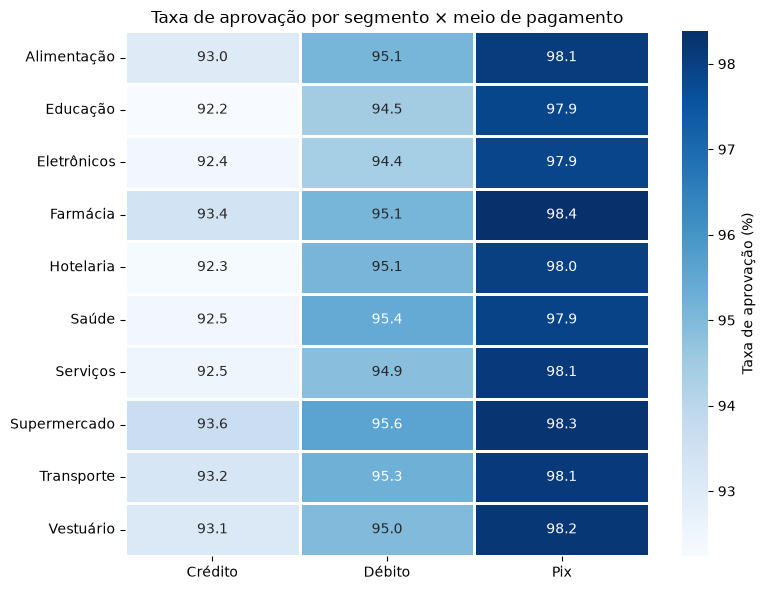

In [221]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    tabela_taxa,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Taxa de aprovação (%)"},
    linewidths=1,
    linecolor="white",
)
plt.title("Taxa de aprovação por segmento × meio de pagamento")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../imagens/heatmap_segmento_meio_pagamento.png", dpi=150)
plt.show()

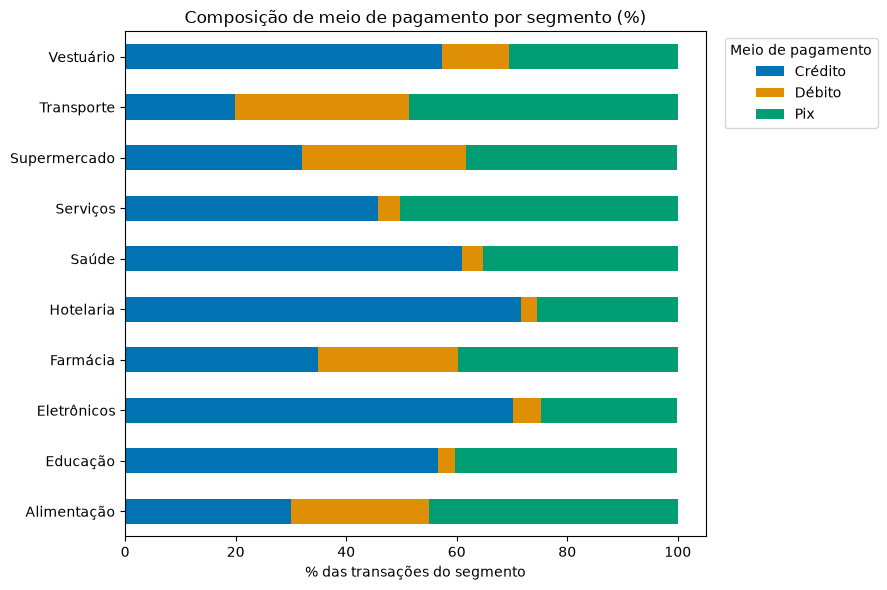

In [222]:
cores_meio_pagamento = sns.color_palette("colorblind", 3)

ax = tabela_composicao.plot(
    kind="barh",
    stacked=True,
    color=cores_meio_pagamento,
    figsize=(9, 6),
)
plt.title("Composição de meio de pagamento por segmento (%)")
plt.xlabel("% das transações do segmento")
plt.ylabel("")
plt.legend(title="Meio de pagamento", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../imagens/composicao_meio_pagamento_por_segmento.png", dpi=150)
plt.show()

### 6.2 Conclusões de negócio

**Conclusão 1: a correção da definição de taxa de aprovação (Seção 2) deve virar padrão em qualquer relatório futuro**

A taxa calculada como aprovadas/total de transações (incluindo Cancelada e Estornada no denominador) difere da taxa correta, aprovadas/(aprovadas+negadas), em 1,2 a 1,3 pontos percentuais. É uma diferença pequena, mas real, e só foi descoberta porque os números deste notebook foram cruzados com um dashboard de Power BI já existente. Recomendação: documentar a definição correta no dicionário de dados do projeto e usá-la como padrão em qualquer análise futura de aprovação, dentro ou fora deste notebook.

**Conclusão 2: meio de pagamento e canal de captura são os únicos fatores operacionais com efeito prático sobre a taxa de aprovação**

Das quatro dimensões testadas formalmente na Seção 2 (meio de pagamento, adquirente, canal, horário; bandeira foi explorada de forma descritiva, sem teste próprio), só meio de pagamento (Cramér's V=0,1065, PIX aprova 98,13% contra 93,48% do cartão) e canal de captura (V=0,0649, POS 95,67% contra Link de Pagamento 90,66%) têm efeito relevante. Adquirente e horário são, na prática, homogêneos, apesar de "estatisticamente significativos" só por causa do volume grande da amostra. Recomendação: qualquer investimento em melhorar taxa de aprovação deve mirar meio de pagamento e canal (negociação com emissores de cartão, revisão do fluxo de Link de Pagamento), não adquirente ou horário de operação.

**Conclusão 3: existe crescimento real ao longo do período, mas a origem dos saltos abruptos não pôde ser explicada pelas variáveis disponíveis**

Existe uma tendência de crescimento estatisticamente robusta (r=0,473, r²≈22%), mas ela ocorre em degraus (fevereiro e junho), não de forma contínua. A hipótese mais provável para esses saltos, entrada de novos parceiros trazendo carteira de estabelecimentos, foi testada em três ângulos independentes (Seção 3.3) e não encontrou suporte nos dados: 97,6% do volume de fevereiro vem de estabelecimentos cadastrados entre 2022 e 2025, não de cadastros novos. Isso não significa que não exista uma causa de negócio real por trás dos saltos, só que as variáveis disponíveis nesta base não a explicam. Como a base também tem características sintéticas, os saltos devem ser interpretados com cautela, não tratados automaticamente como comportamento real de mercado. Recomendação: qualquer leitura de tendência de crescimento feita sobre esta base deve vir acompanhada dessa ressalva metodológica.

**Conclusão 4: segmento de atuação é o fator estrutural mais forte do projeto, e seu efeito sobre a taxa de aprovação é compatível com mediação pelo mix de meio de pagamento**

Segmento explica a maior fatia de variância tanto de volume por estabelecimento (ηp²=0,111) quanto de taxa de aprovação (ηp²=0,351, confirmado por Kruskal-Wallis, H=192,95, p<0,001). Mas quando a taxa é comparada dentro do mesmo meio de pagamento, a diferença entre segmentos cai para menos de 1,5 ponto percentual, o que sustenta que o mix de meio de pagamento de cada segmento (Hotelaria com 71,6% de cartão de crédito, o meio de menor aprovação, é o exemplo mais claro) parece explicar boa parte da associação observada, mais do que um efeito direto de "categoria de negócio". Essa estratificação é evidência de explicação composicional, não uma prova estatística formal de uma cadeia causal, isso exigiria um desenho de mediação dedicado. Recomendação: modelos e políticas de risco não devem tratar segmento como causa direta da taxa de aprovação. A composição de meio de pagamento parece ser o fator de risco operacional mais próximo da causa real; segmento funciona como proxy útil para identificar exposição a meios de pagamento de maior risco, e a etapa preditiva pode testar isso diretamente comparando `aprovação ~ segmento` com `aprovação ~ segmento + meio_pagamento`.

**Conclusão 5: 45 estabelecimentos estão há mais de 30 dias sem transacionar; 39 deles seguem Pendente e formam o grupo prioritário de investigação**

45 dos 500 estabelecimentos cadastrados (9%) nunca transacionaram, mesmo com mais de 30 (até 120) dias desde o cadastro (Seção 4.4). Desses, 39 seguem com status "Pendente", sem uma explicação de status para a ausência de transação, e são o grupo genuinamente acionável; os outros 6 já estão Bloqueado ou Inativo, o que por si só explica por que não transacionaram. Diferente das outras conclusões, este achado não veio de um teste de hipótese, veio de auditoria direta dos dados. Recomendação: encaminhar a lista dos 39 (por `estabelecimento_id`) para o time de onboarding/ativação validar se é falha de processo ou característica da base.

**Conclusão 6: seis colunas da tabela `transacoes` são vazamento de dados e precisam ser excluídas de qualquer modelo preditivo**

`codigo_autorizacao`, `txid_pix`, `motivo_negativa_id`, `valor_taxa`, `valor_liquido` e `tempo_processamento_ms` são, cada uma à sua forma, geradas como consequência ou durante o processo de decisão de aprovação (Seção 5), e não estariam disponíveis no momento em que um modelo precisaria prever esse resultado. Recomendação: excluir as seis colunas do conjunto de features na etapa de Feature Engineering, como pré-requisito, não como opção a se considerar.

### Síntese da Seção 6 e encerramento do notebook

Este notebook fechou os pontos de EDA complementar que tinham ficado fora do `01_distribuicao_transacoes.ipynb`: qualidade dos dados, segmentação por dimensão operacional, comportamento temporal, concentração e atipicidade por estabelecimento, vazamento de dados e, por fim, a consolidação das seis conclusões acima. As conclusões com significância estatística e efeito prático relevante (2, 4, 5 e 6) devem orientar diretamente as próximas etapas do projeto; as conclusões metodológicas (1 e 3) funcionam mais como ressalva de como interpretar os números do que como achado de negócio em si.

**Próximos passos (fora deste notebook):** atualizar o README do projeto com o resumo executivo dessas seis conclusões e, só então, iniciar a etapa de Feature Engineering, já com a lista de colunas vazadas (Conclusão 6) e a composição de meio de pagamento por segmento (Conclusão 4) em mente desde o desenho das features.